# LDA Analyses (LEC)

Split from `LEC_sploratory_analysis_with_glm_and_population.ipynb`. This notebook bundles three linear-discriminant-analysis (LDA) flavours used on LEC population data:

1. **State separation (trial-bins)** — 4-class LDA discriminating task states A/B/C/D, fit on per-(trial × state) z-scored population vectors. Includes leave-one-session-out CV.
2. **Pillai-trace separability** — same dataset, but quantifies separability via Pillai's trace on the W⁻¹B eigenspectrum, with a roll-shuffle null on the raw recordings.
3. **Goal-progress LDA** — same 4-class LDA fit separately within early/middle/late goal-progress bins.
4. **Reward × goal-progress LDA** — joint decoding of reward number and goal-progress phase.

Backed by [`lda_state_analysis_trialbins.py`](lda_state_analysis_trialbins.py), [`lda_state_analysis_goalprogress.py`](lda_state_analysis_goalprogress.py), [`lda_reward_goalprogress.py`](lda_reward_goalprogress.py).

## Method notes

**Trial extraction (state separation)**: each session's raw recording is z-scored across the concatenated timeline, then for every (trial, state) the mean population vector is taken across the state's raw time window. The result is a matrix $X \in \mathbb{R}^{N \times n_{neurons}}$ labelled by state $\in \{A,B,C,D\}$.

**Pillai's trace**: the sum $\sum_i \lambda_i / (1 + \lambda_i)$ over eigenvalues of $W^{-1}B$ where $W$ is the within-class scatter and $B$ is the between-class scatter. Bounded in $[0, n_{classes} - 1]$; equals 0 when classes are inseparable, approaches $n_{classes} - 1$ when perfectly separable.

**Roll-shuffle null**: each session's raw recording is circularly rolled by a random offset (at least one mean trial length) before re-running the full pipeline. This preserves autocorrelation structure while destroying state-activity alignment.

**Trial balancing** (new flag): if `balance_trials_per_task=True`, each session's trials are subsampled to `min(n_trials)` across sessions *before* trial-state extraction. The z-score still uses the full raw recording for stable normalisation. Prevents tasks with more trials from dominating the within-state scatter matrix. Applied identically to real and shuffled data.

In [52]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle
from importlib import reload


In [53]:
Data_folder="../data/processed_data"
figures_folder="../data/figures"
neuron_folder = f"{Data_folder}/neuron_raw_mingyutest"
trialtimes_folder = f"{Data_folder}/trialtimes_raw_mingyutest"
tracking_folder = f"{Data_folder}/processed"


In [54]:
import pickle
import os

# Define the folder where the processed data is saved
processed_data_folder = "../data/processed_data"

# Load the main data dictionary
with open(os.path.join(processed_data_folder, 'data_dic_for_yaren.pkl'), 'rb') as f:
    data_dic = pickle.load(f)

# Load the normalized neurons dictionary
with open(os.path.join(processed_data_folder, 'norm_neurons_dic.pkl'), 'rb') as f:
    norm_neurons_dic = pickle.load(f)

# Load the session indices dictionary
with open(os.path.join(processed_data_folder, 'session_inds_dic.pkl'), 'rb') as f:
    session_inds_dic = pickle.load(f)

# Load the tasks dictionary
with open(os.path.join(processed_data_folder, 'tasks_dic.pkl'), 'rb') as f:
    tasks_dic = pickle.load(f)

print(f"Loaded data dictionaries from {processed_data_folder}")


Loaded data dictionaries from ../data/processed_data


In [55]:
all_files = os.listdir(neuron_folder)
neuron_files = [f for f in all_files if f.startswith('Neuron_raw_') and f.endswith('.npy')]

mouse_recdays_ = []
for f in neuron_files:
    # Remove prefix 'Neuron_raw_' and suffix '.npy'
    stripped_name = f[len('Neuron_raw_'):-len('.npy')]
    # Split by '_' and rejoin all parts except the last one (session number)
    mouse_recday = '_'.join(stripped_name.split('_')[:-1])
    mouse_recdays_.append(mouse_recday)

# Find the unique mouse_recday identifiers
mouse_recdays = np.unique(mouse_recdays_)

# Filter out identifiers containing '_sb'
unique_mouse_recdays = [recday for recday in mouse_recdays if '_sb' not in recday]

print("Unique mouse_recday identifiers (without '_sb'):")
print(unique_mouse_recdays)

# Assign the first unique identifier to mouse_recday for later use
if len(unique_mouse_recdays) > 0:
    mouse_recday = unique_mouse_recdays[0]

mouse_recdays = unique_mouse_recdays


Unique mouse_recday identifiers (without '_sb'):
[np.str_('ah08_20250613_20250615'), np.str_('ah08_20250616_20250617'), np.str_('ah08_20250618_20250619'), np.str_('ah08_20250620_20250623'), np.str_('ah08_20250624_20250625'), np.str_('ah10_20250613_20250615'), np.str_('ah10_20250616_20250617'), np.str_('ah10_20250618_20250619'), np.str_('ah10_20250620_20250623'), np.str_('ah10_20250624_20250625'), np.str_('ly05_20250613_20250615'), np.str_('ly05_20250616_20250617'), np.str_('ly05_20250618_20250619'), np.str_('ly05_20250624_20250625'), np.str_('ly06_20250613_20250615'), np.str_('ly06_20250616_20250617'), np.str_('ly06_20250618_20250619'), np.str_('ly06_20250620_20250623'), np.str_('ly06_20250624_20250625'), np.str_('ly07_20250613_20250615'), np.str_('ly07_20250616_20250617'), np.str_('ly07_20250618_20250619'), np.str_('ly07_20250620_20250623'), np.str_('ly07_20250624_20250625')]


In [56]:
# Build valid_sessions_dic: for each mouse_recday, keep one session per unique task structure
valid_sessions_dic = {}
for mouse_recday in mouse_recdays:
    valid_sessions = []
    tasks = []
    for session in list(data_dic[mouse_recday].keys()):
        if session == 'valid_sessions':
            continue
        if data_dic[mouse_recday][session]['num_trials'] < 5:
            print(f'{mouse_recday} session {session}: not enough trials, skipping')
            continue
        if 'defaultdict' in str(data_dic[mouse_recday][session]['Task']):
            print(f'{mouse_recday} session {session}: no task, skipping')
            continue
        if not any(np.array_equal(data_dic[mouse_recday][session]['Task'], candidate) for candidate in tasks):
            tasks.append(data_dic[mouse_recday][session]['Task'])
            valid_sessions.append(session)
    print(f'{mouse_recday}: {valid_sessions}')
    valid_sessions_dic[mouse_recday] = valid_sessions

ah08_20250613_20250615 session 7: not enough trials, skipping
ah08_20250613_20250615: [0, 1, 2, 4, 5, 6]
ah08_20250616_20250617 session 2: not enough trials, skipping
ah08_20250616_20250617 session 7: not enough trials, skipping
ah08_20250616_20250617: [0, 1, 4, 5, 6]
ah08_20250618_20250619 session 7: not enough trials, skipping
ah08_20250618_20250619: [0, 1, 2, 4, 5, 6]
ah08_20250620_20250623 session 3: not enough trials, skipping
ah08_20250620_20250623 session 6: not enough trials, skipping
ah08_20250620_20250623 session 7: not enough trials, skipping
ah08_20250620_20250623: [0, 1, 2, 4, 5]
ah08_20250624_20250625 session 1: not enough trials, skipping
ah08_20250624_20250625 session 3: not enough trials, skipping
ah08_20250624_20250625 session 4: not enough trials, skipping
ah08_20250624_20250625 session 5: not enough trials, skipping
ah08_20250624_20250625 session 8: not enough trials, skipping
ah08_20250624_20250625 session 9: not enough trials, skipping
ah08_20250624_20250625 sessi

## State separation LDA (trial-bins)


Trial-bin LDA analysis: ah08_20250613_20250615
Sessions: [0, 1, 2, 4, 5, 6]
Task is [3 2 7 1]
Task is [3 4 6 7]
Task is [7 5 1 6]
Task is [6 4 9 2]
Task is [7 9 5 4]
Task is [7 3 1 5]
ah08_20250613_20250615: 6 sessions, 151 neurons
  Session 0 (index 0): 5 trials, T=45293 samples
  Session 1 (index 1): 9 trials, T=46043 samples
  Session 2 (index 2): 7 trials, T=40895 samples
  Session 4 (index 3): 11 trials, T=46785 samples
  Session 5 (index 4): 21 trials, T=48367 samples
  Session 6 (index 5): 10 trials, T=45850 samples
(array([0, 1, 2, 3, 4, 5]), array([20, 36, 28, 44, 84, 40]))
  Dataset: 252 samples (0 skipped) from 252 (trial, state) pairs
  PCA: keeping 23/151 PCs (75.3% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 252
Number of LDA components: 3
Explained variance ratio: [0.46002399 0.39164091 0.14833509]


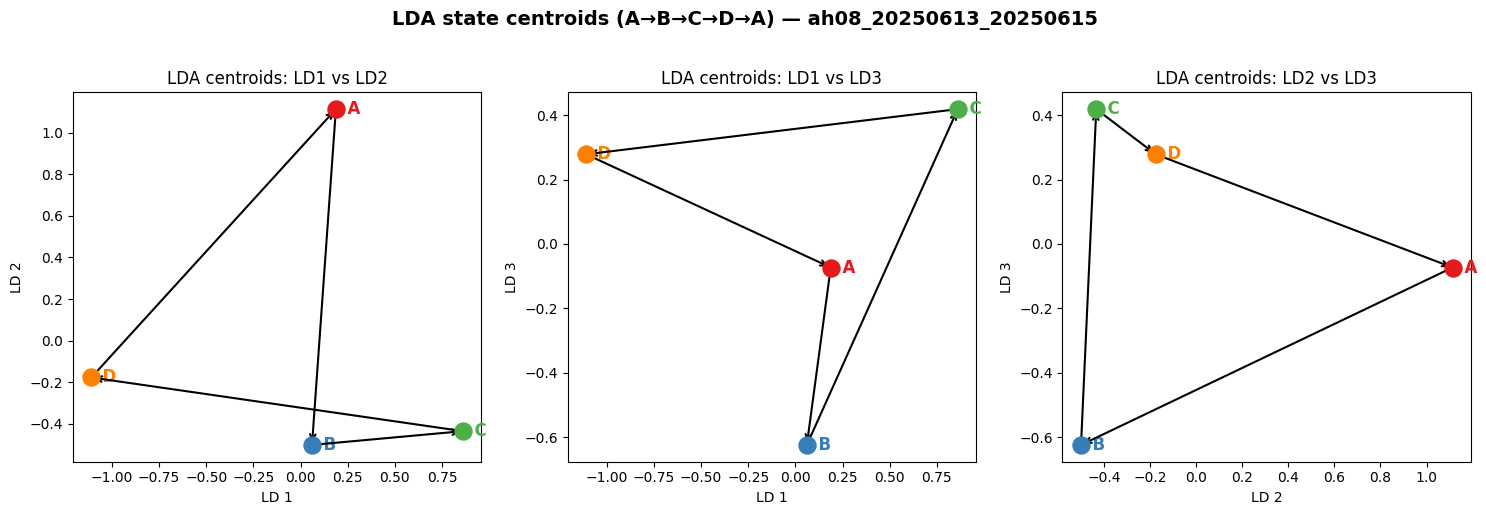

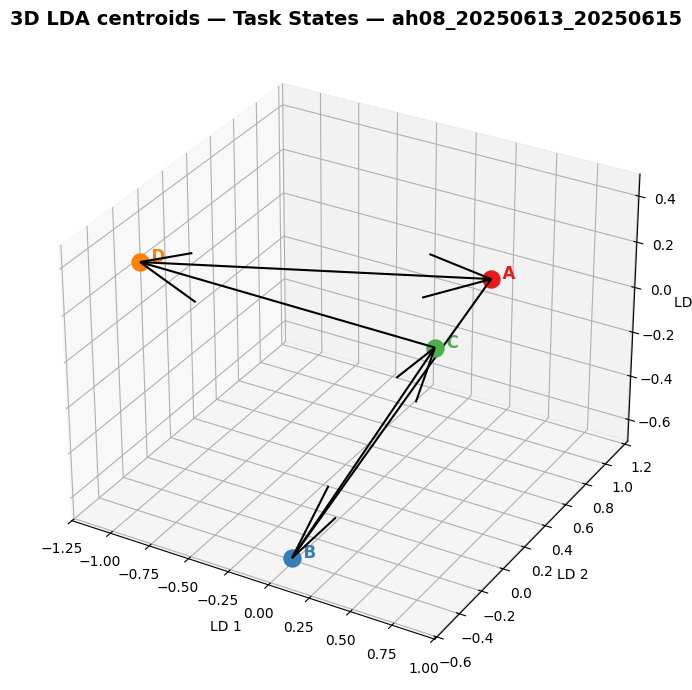

Working with sessions [0 1 2 3 4 5] (total 6)


/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classif

Leave-one-session-out CV (6 sessions)
Real CV balanced accuracy: 0.240
Null: 0.250 ± 0.028
p = 0.6290


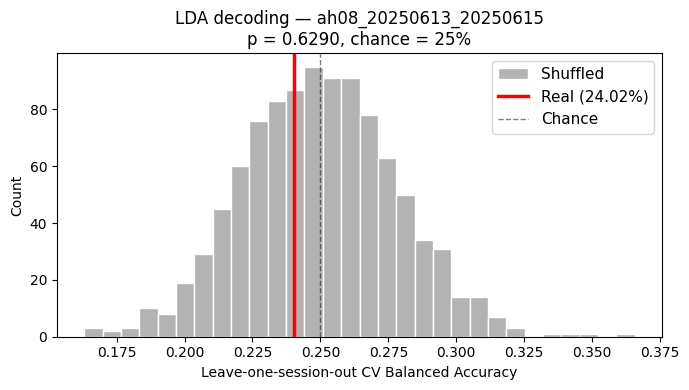

Computing null centroids with 1000 circular label rolls...


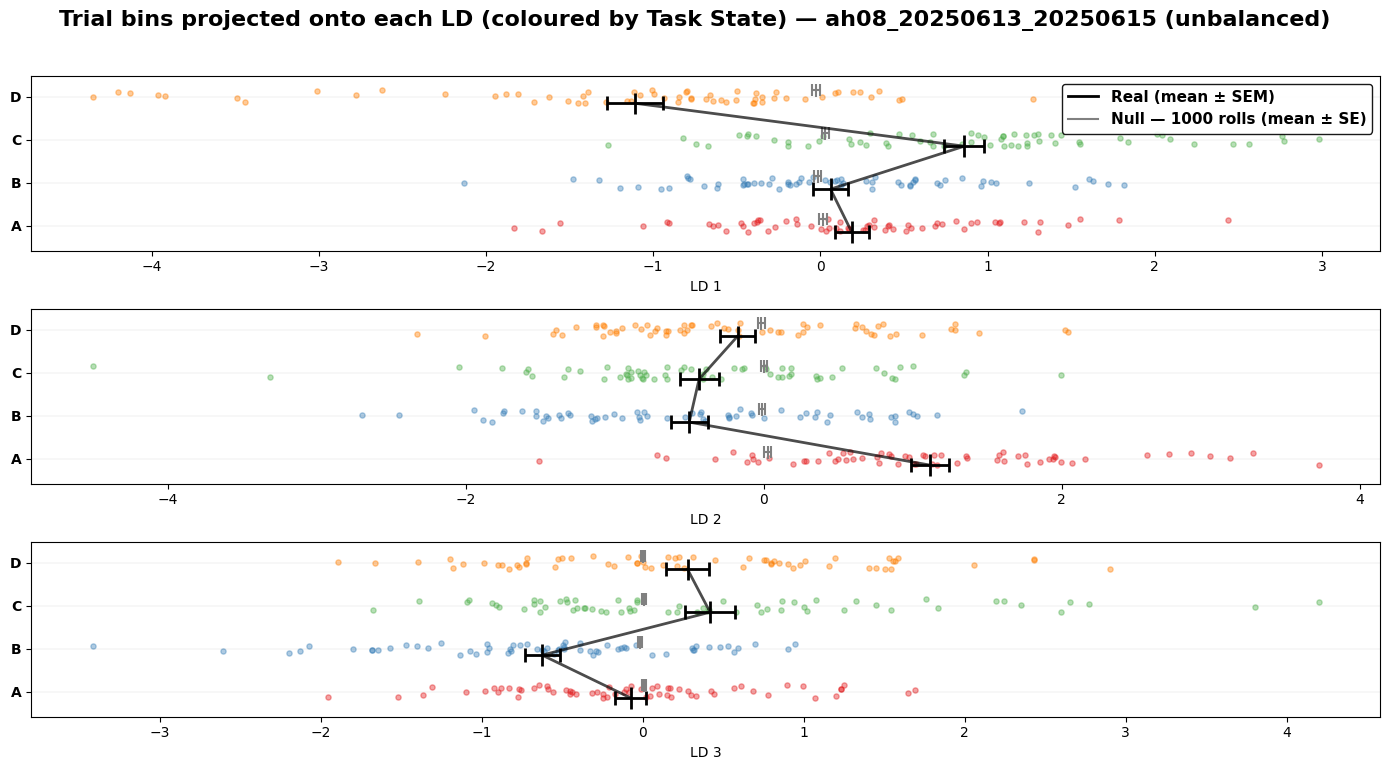

In [57]:
import lda_state_analysis_trialbins
import lda_state_separation
reload(lda_state_analysis_trialbins)
reload(lda_state_separation)
from lda_state_analysis_trialbins import run_trialbins_lda_analysis, plot_ld_projections
from lda_state_analysis_trialbins import EVENT_LABELS, EVENT_COLOURS

mouse_recday = mouse_recdays[0]

results_unbalanced = run_trialbins_lda_analysis(
    data_dic, mouse_recday,
    valid_sessions=valid_sessions_dic[mouse_recday],
    neuron_subset=None,
    balance_trials_per_task=False,
)
plot_ld_projections(results_unbalanced['X_state_ld'], results_unbalanced['y_state'],
                    EVENT_LABELS, EVENT_COLOURS, f'{mouse_recday} (unbalanced)')

## Trial-balanced state separation

Same analysis as above, but with `balance_trials_per_task=True` — each session's trials are subsampled to `min(n_trials)` across sessions before (trial, state) vector extraction. Sample count drops accordingly; class balance per state is preserved across tasks.


Trial-bin LDA analysis: ah08_20250613_20250615
Sessions: [0, 1, 2, 4, 5, 6]
Task is [3 2 7 1]
Task is [3 4 6 7]
Task is [7 5 1 6]
Task is [6 4 9 2]
Task is [7 9 5 4]
Task is [7 3 1 5]
ah08_20250613_20250615: 6 sessions, 151 neurons
  Balancing trials per task: keeping 5 per session (originally [5, 9, 7, 11, 21, 10])


  Session 0 (index 0): 5 trials, T=45293 samples
  Session 1 (index 1): 5 trials, T=46043 samples
  Session 2 (index 2): 5 trials, T=40895 samples
  Session 4 (index 3): 5 trials, T=46785 samples
  Session 5 (index 4): 5 trials, T=48367 samples
  Session 6 (index 5): 5 trials, T=45850 samples
(array([0, 1, 2, 3, 4, 5]), array([20, 20, 20, 20, 20, 20]))
  Dataset: 120 samples (0 skipped) from 120 (trial, state) pairs
  PCA: keeping 18/120 PCs (75.2% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 120
Number of LDA components: 3
Explained variance ratio: [0.52261455 0.27107719 0.20630826]


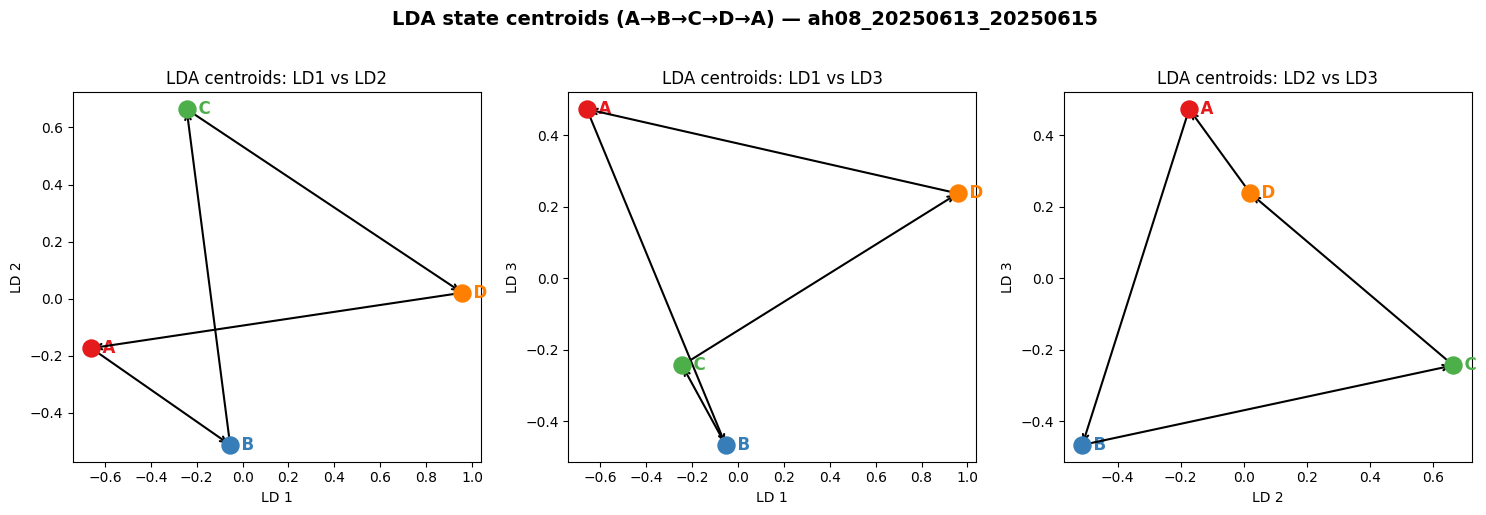

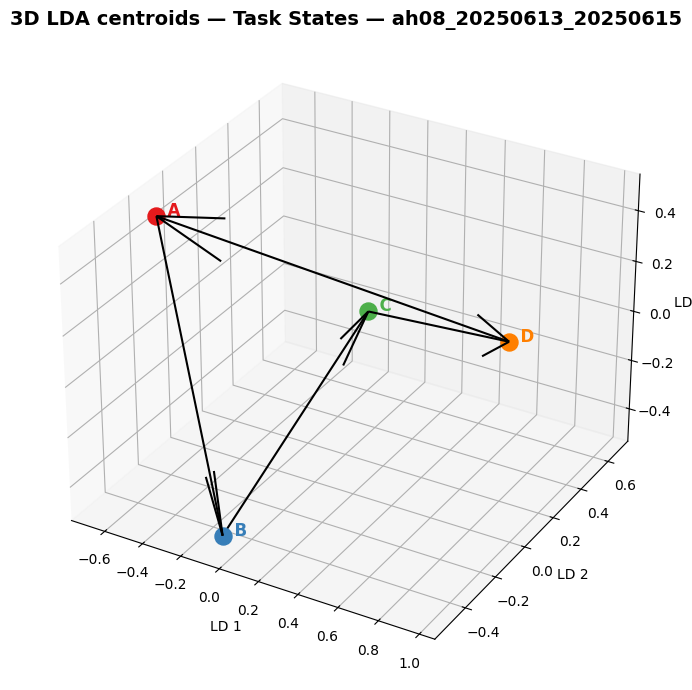

Working with sessions [0 1 2 3 4 5] (total 6)


/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/nfs/nhome/live/aharris/.conda/envs/maze_ephys/lib/python3.12/site-packages/sklearn/metrics/_classif

Leave-one-session-out CV (6 sessions)
Real CV balanced accuracy: 0.242
Null: 0.249 ± 0.039
p = 0.5750


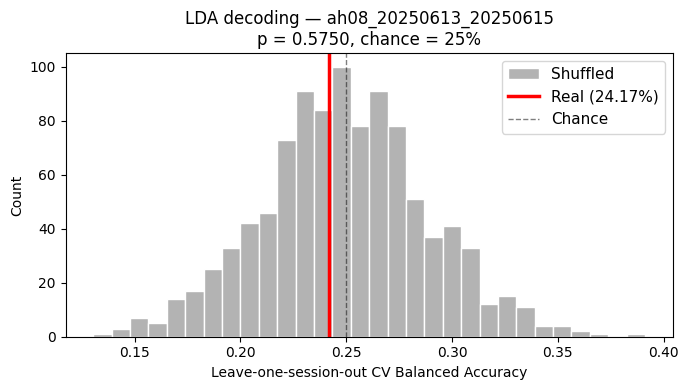

Computing null centroids with 1000 circular label rolls...


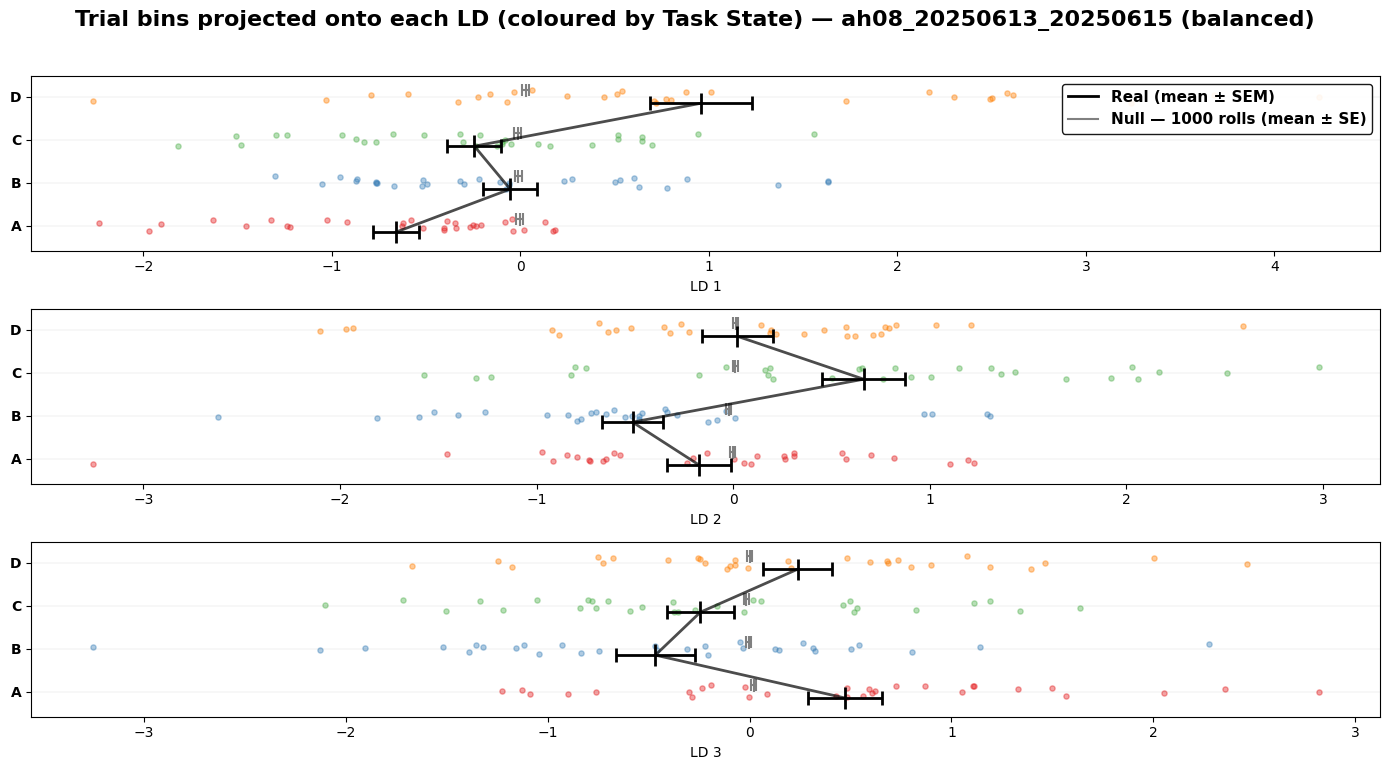

Unbalanced samples: 252
Balanced samples:   120
Unbalanced LOGO CV acc: 0.240 (p=0.6290)
Balanced LOGO CV acc:   0.242 (p=0.5750)


In [58]:
results_balanced = run_trialbins_lda_analysis(
    data_dic, mouse_recday,
    valid_sessions=valid_sessions_dic[mouse_recday],
    neuron_subset=None,
    balance_trials_per_task=True,
    balance_rng_seed=42,
)
plot_ld_projections(results_balanced['X_state_ld'], results_balanced['y_state'],
                    EVENT_LABELS, EVENT_COLOURS, f'{mouse_recday} (balanced)')

print(f"Unbalanced samples: {results_unbalanced['X'].shape[0]}")
print(f"Balanced samples:   {results_balanced['X'].shape[0]}")
print(f"Unbalanced LOGO CV acc: {results_unbalanced['real_acc']:.3f} (p={results_unbalanced['p_value']:.4f})")
print(f"Balanced LOGO CV acc:   {results_balanced['real_acc']:.3f} (p={results_balanced['p_value']:.4f})")

## Pillai-trace separability (trial-balanced)

Fits the same 4-class LDA but reports Pillai's trace and the per-LD eigenvalues, with a roll-shuffle null on the raw recordings. Trial balancing is on by default here.

ah08_20250613_20250615: 6 sessions, 151 neurons
  Balancing trials per task: keeping 5 per session (originally [5, 9, 7, 11, 21, 10])


  Real Pillai = 0.5533 | eigenvalues: [0.366 0.19  0.144]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


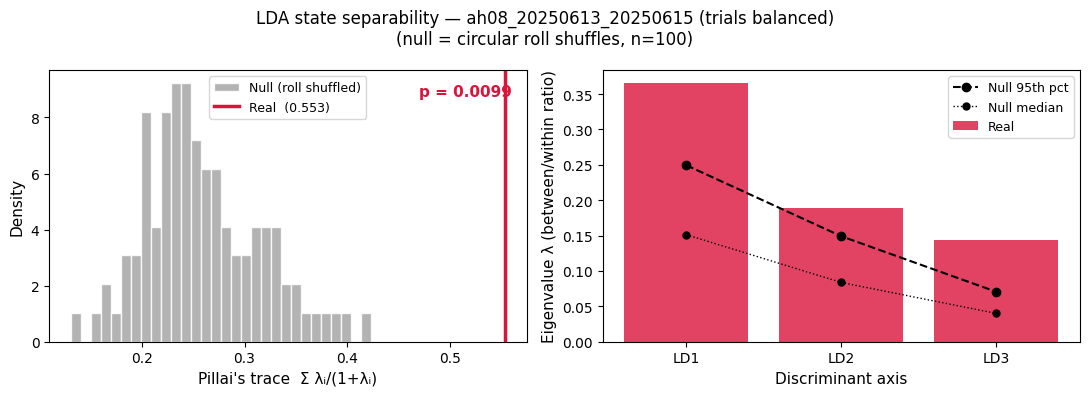

Pillai=0.5533, p=0.0099
Eigenvalues: [0.366 0.19  0.144]
ah08_20250616_20250617: 5 sessions, 164 neurons
  Balancing trials per task: keeping 13 per session (originally [15, 13, 16, 15, 14])
  Real Pillai = 0.9770 | eigenvalues: [0.805 0.588 0.192]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


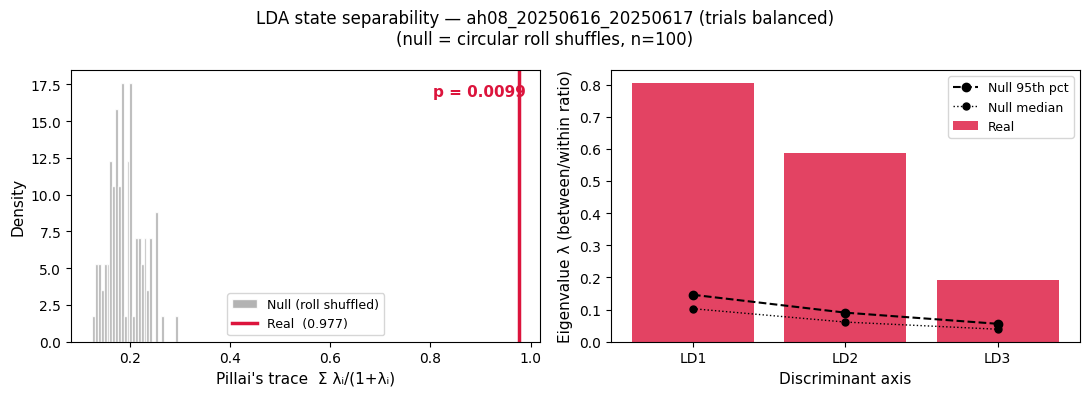

Pillai=0.9770, p=0.0099
Eigenvalues: [0.805 0.588 0.192]
ah08_20250618_20250619: 6 sessions, 183 neurons
  Balancing trials per task: keeping 7 per session (originally [22, 15, 21, 23, 11, 7])
  Real Pillai = 0.5828 | eigenvalues: [0.393 0.273 0.095]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


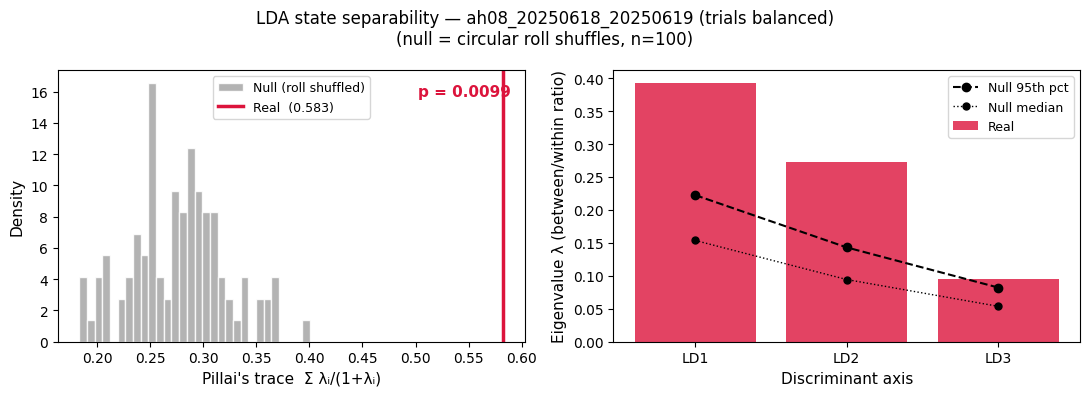

Pillai=0.5828, p=0.0099
Eigenvalues: [0.393 0.273 0.095]
ah08_20250620_20250623: 5 sessions, 108 neurons
  Balancing trials per task: keeping 10 per session (originally [23, 22, 22, 10, 18])
  Real Pillai = 0.7193 | eigenvalues: [0.959 0.255 0.027]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


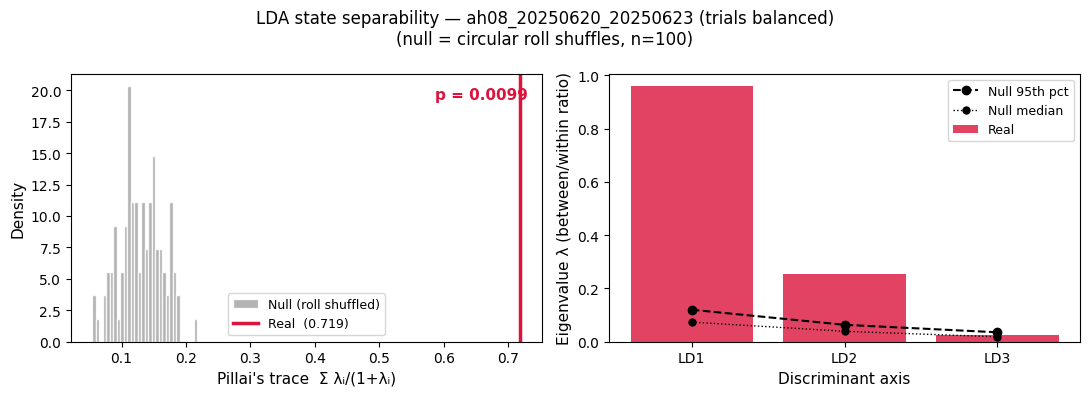

Pillai=0.7193, p=0.0099
Eigenvalues: [0.959 0.255 0.027]
ah08_20250624_20250625: 4 sessions, 186 neurons
  Balancing trials per task: keeping 5 per session (originally [14, 7, 10, 5])
  Real Pillai = 1.0270 | eigenvalues: [0.85  0.476 0.324]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


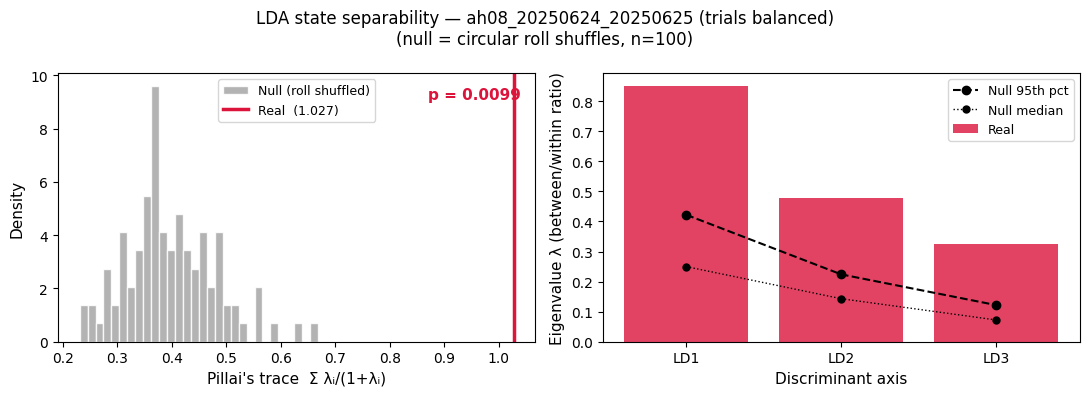

Pillai=1.0270, p=0.0099
Eigenvalues: [0.85  0.476 0.324]
ah10_20250613_20250615: 6 sessions, 139 neurons
  Balancing trials per task: keeping 18 per session (originally [18, 42, 22, 37, 29, 25])
  Real Pillai = 0.4985 | eigenvalues: [0.304 0.2   0.11 ]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


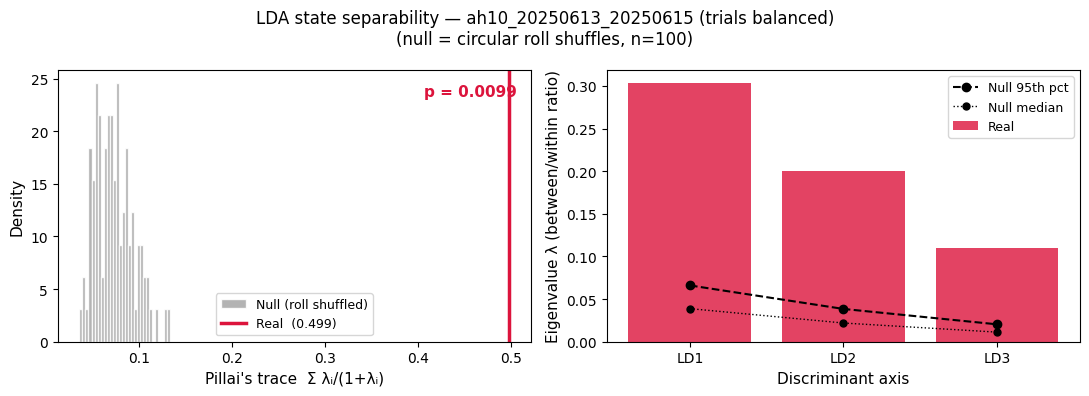

Pillai=0.4985, p=0.0099
Eigenvalues: [0.304 0.2   0.11 ]
ah10_20250616_20250617: 6 sessions, 154 neurons
  Balancing trials per task: keeping 18 per session (originally [22, 25, 23, 18, 25, 30])
  Real Pillai = 0.7092 | eigenvalues: [0.546 0.261 0.175]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


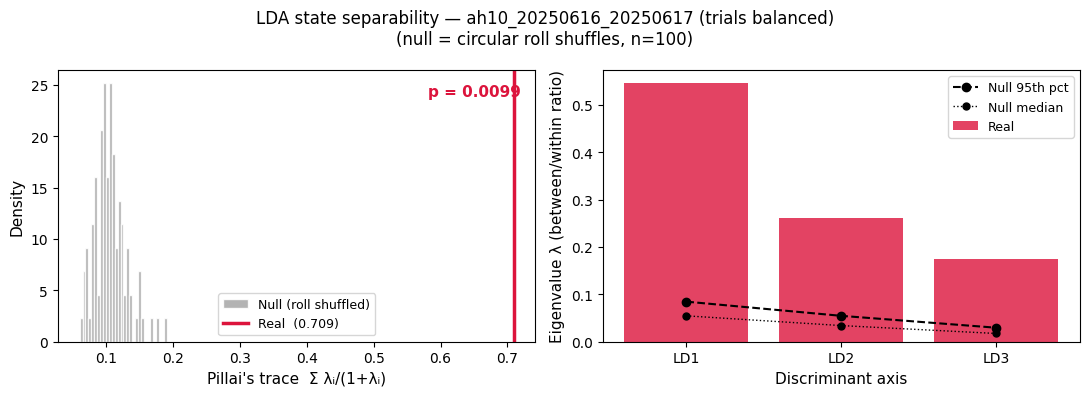

Pillai=0.7092, p=0.0099
Eigenvalues: [0.546 0.261 0.175]
ah10_20250618_20250619: 6 sessions, 162 neurons
  Balancing trials per task: keeping 21 per session (originally [21, 34, 30, 25, 29, 31])
  Real Pillai = 0.5919 | eigenvalues: [0.457 0.23  0.1  ]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


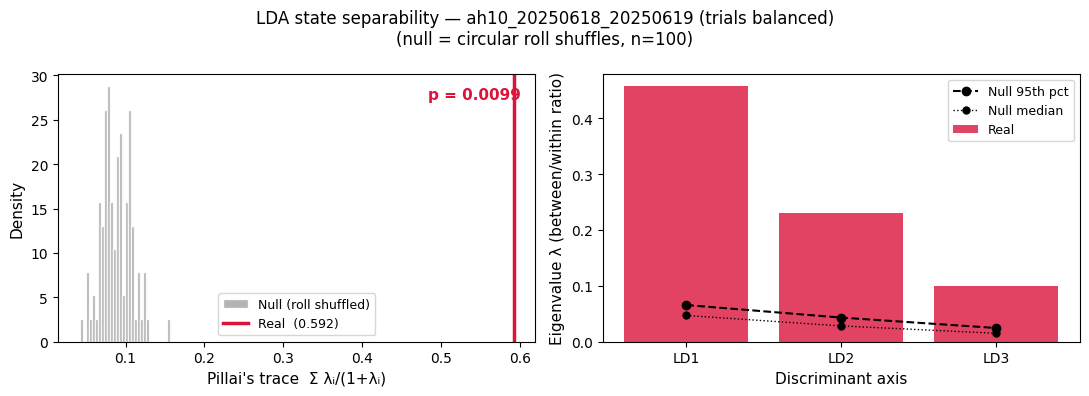

Pillai=0.5919, p=0.0099
Eigenvalues: [0.457 0.23  0.1  ]
ah10_20250620_20250623: 6 sessions, 153 neurons
  Balancing trials per task: keeping 22 per session (originally [22, 26, 31, 31, 32, 42])
  Real Pillai = 0.6713 | eigenvalues: [0.539 0.252 0.136]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


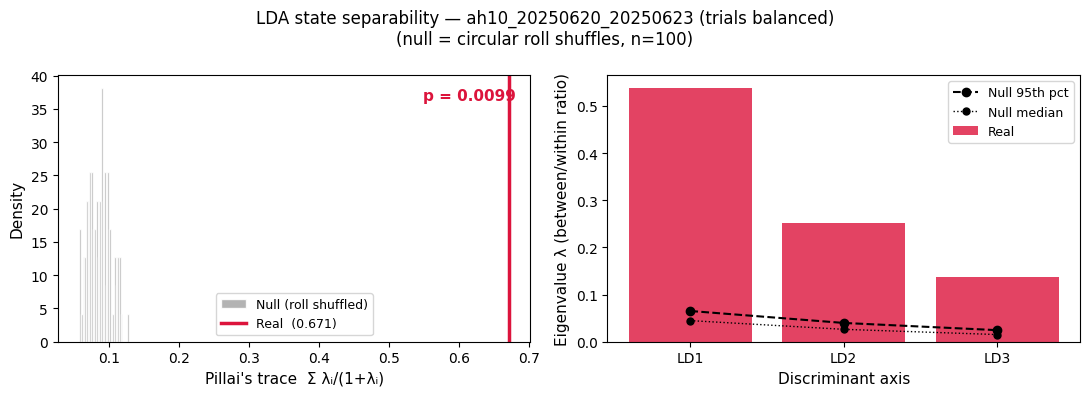

Pillai=0.6713, p=0.0099
Eigenvalues: [0.539 0.252 0.136]
ah10_20250624_20250625: 6 sessions, 164 neurons
  Balancing trials per task: keeping 21 per session (originally [31, 33, 23, 28, 21, 30])
  Real Pillai = 0.5910 | eigenvalues: [0.609 0.187 0.058]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


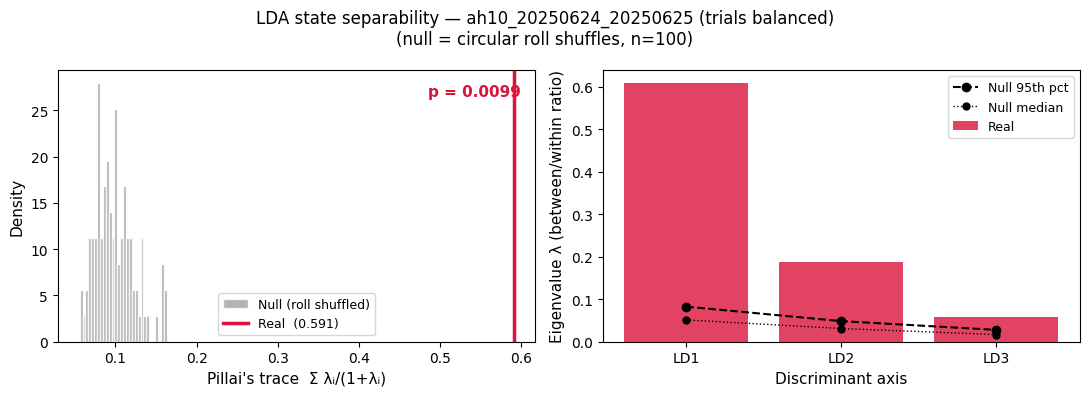

Pillai=0.5910, p=0.0099
Eigenvalues: [0.609 0.187 0.058]
ly05_20250613_20250615: 5 sessions, 117 neurons
  Balancing trials per task: keeping 5 per session (originally [8, 20, 22, 21, 5])
  Real Pillai = 0.4859 | eigenvalues: [0.439 0.142 0.06 ]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


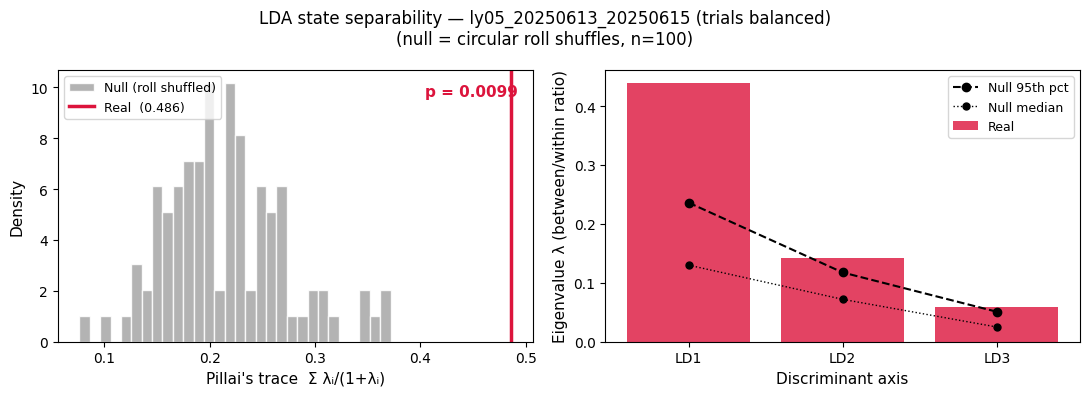

Pillai=0.4859, p=0.0099
Eigenvalues: [0.439 0.142 0.06 ]
ly05_20250616_20250617: 6 sessions, 116 neurons
  Balancing trials per task: keeping 7 per session (originally [28, 16, 8, 7, 9, 7])
  Real Pillai = 0.1887 | eigenvalues: [0.113 0.056 0.035]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0297  (n_valid_shuffles = 100)


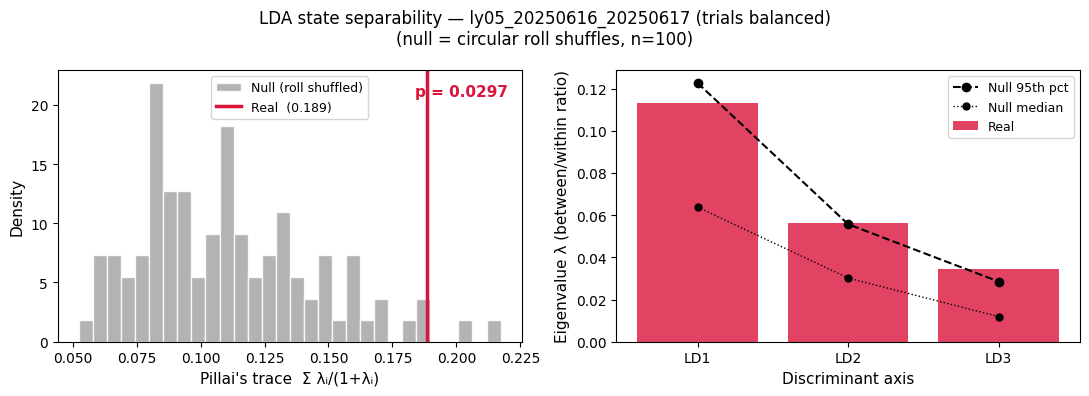

Pillai=0.1887, p=0.0297
Eigenvalues: [0.113 0.056 0.035]
ly05_20250618_20250619: 4 sessions, 91 neurons
  Balancing trials per task: keeping 6 per session (originally [8, 13, 6, 8])
  Real Pillai = 0.1850 | eigenvalues: [0.144 0.059 0.004]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.1584  (n_valid_shuffles = 100)


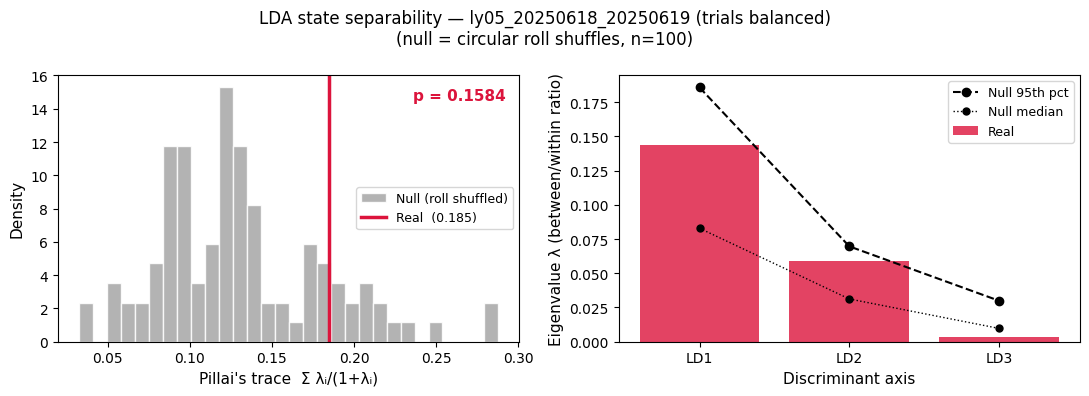

Pillai=0.1850, p=0.1584
Eigenvalues: [0.144 0.059 0.004]
ly05_20250624_20250625: 4 sessions, 74 neurons
  Balancing trials per task: keeping 9 per session (originally [16, 9, 19, 10])
  Real Pillai = 0.7418 | eigenvalues: [0.584 0.262 0.198]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


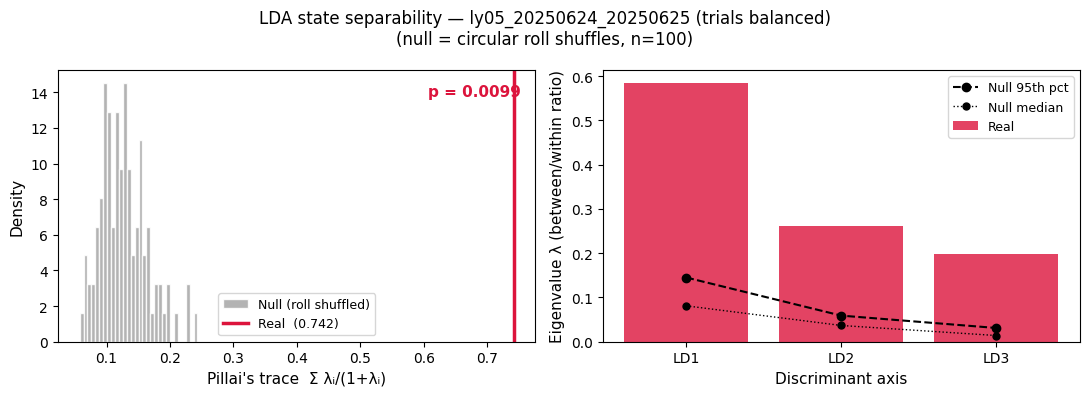

Pillai=0.7418, p=0.0099
Eigenvalues: [0.584 0.262 0.198]
ly06_20250613_20250615: 6 sessions, 68 neurons
  Balancing trials per task: keeping 8 per session (originally [10, 15, 8, 28, 18, 40])
  Real Pillai = 0.1097 | eigenvalues: [0.067 0.027 0.02 ]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0396  (n_valid_shuffles = 100)


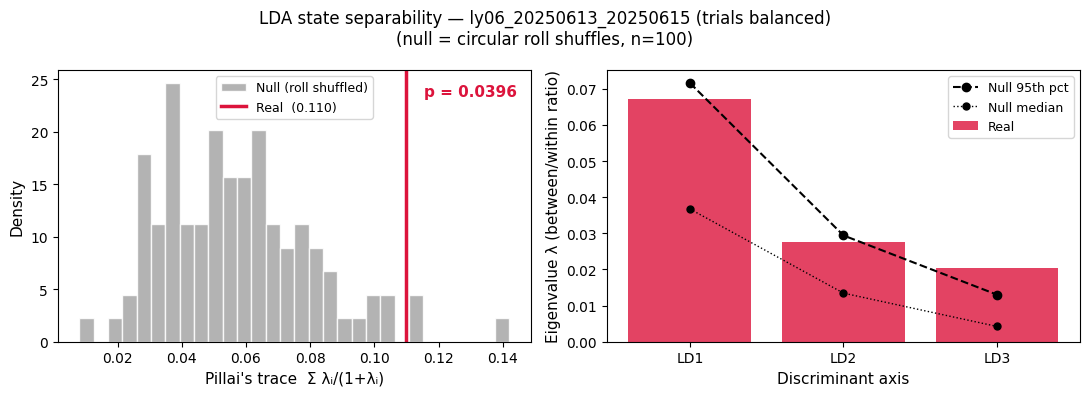

Pillai=0.1097, p=0.0396
Eigenvalues: [0.067 0.027 0.02 ]
ly06_20250616_20250617: 6 sessions, 79 neurons
  Balancing trials per task: keeping 5 per session (originally [18, 33, 5, 25, 11, 17])
  Real Pillai = 0.2821 | eigenvalues: [0.27  0.047 0.025]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


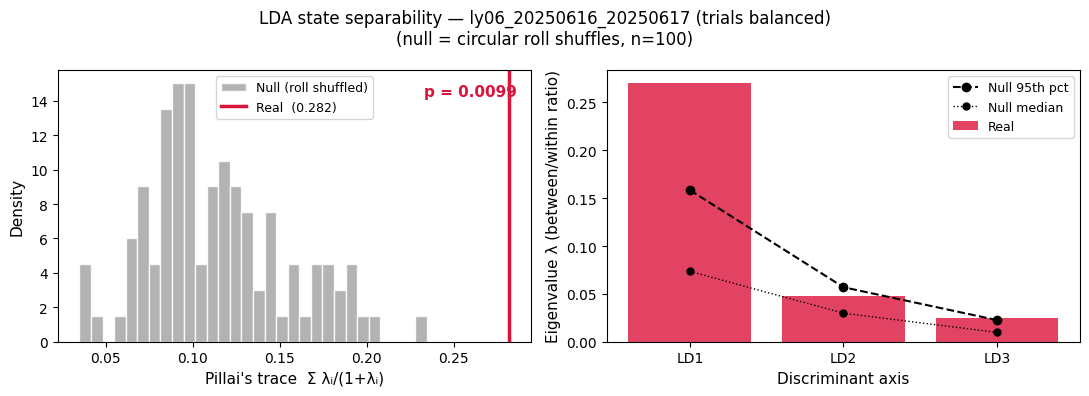

Pillai=0.2821, p=0.0099
Eigenvalues: [0.27  0.047 0.025]
ly06_20250618_20250619: 7 sessions, 76 neurons
  Balancing trials per task: keeping 8 per session (originally [17, 10, 8, 21, 15, 20, 16])
  Real Pillai = 0.2325 | eigenvalues: [0.171 0.07  0.022]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


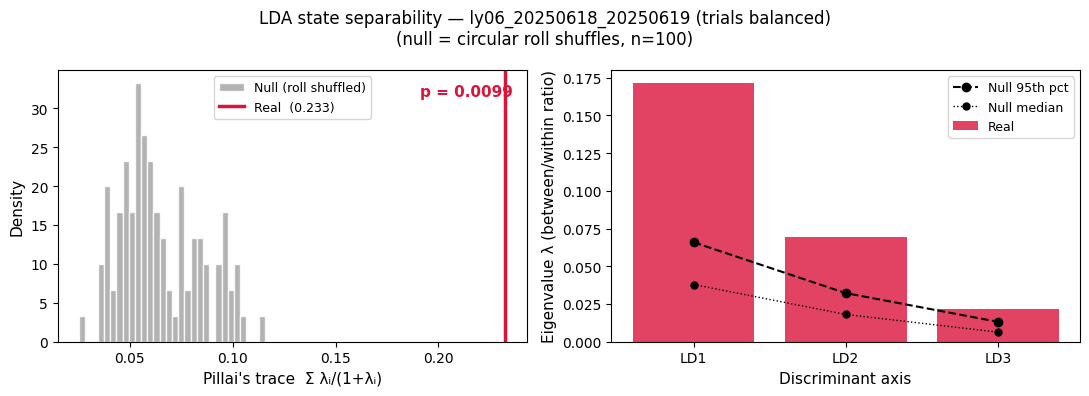

Pillai=0.2325, p=0.0099
Eigenvalues: [0.171 0.07  0.022]
ly06_20250620_20250623: 5 sessions, 67 neurons
  Balancing trials per task: keeping 5 per session (originally [27, 5, 28, 30, 12])
  Real Pillai = 0.2308 | eigenvalues: [0.13  0.105 0.021]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0594  (n_valid_shuffles = 100)


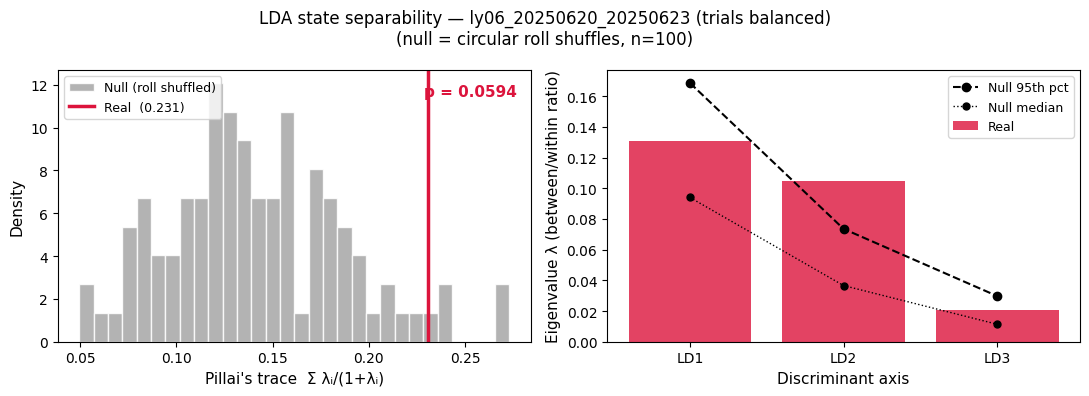

Pillai=0.2308, p=0.0594
Eigenvalues: [0.13  0.105 0.021]
ly06_20250624_20250625: 6 sessions, 66 neurons
  Balancing trials per task: keeping 7 per session (originally [28, 18, 20, 24, 7, 21])
  Real Pillai = 0.2716 | eigenvalues: [0.165 0.083 0.057]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


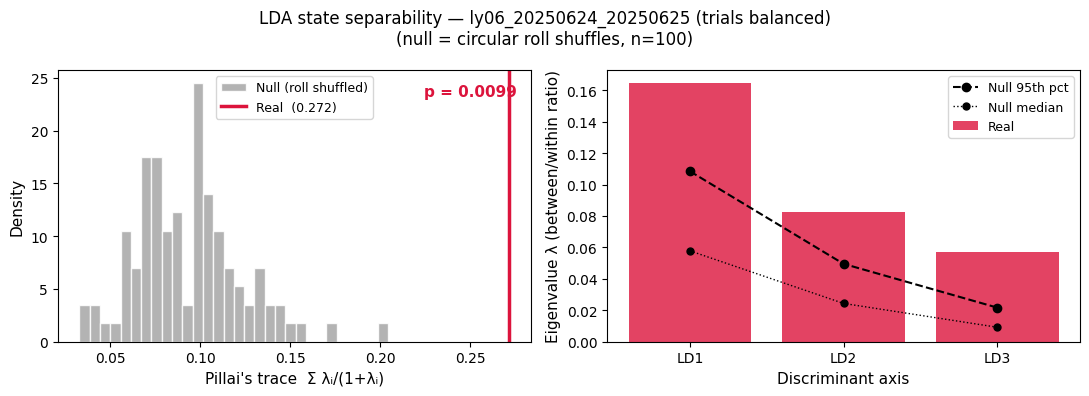

Pillai=0.2716, p=0.0099
Eigenvalues: [0.165 0.083 0.057]
ly07_20250613_20250615: 6 sessions, 73 neurons
  Balancing trials per task: keeping 9 per session (originally [31, 27, 29, 33, 9, 18])
  Real Pillai = 0.4296 | eigenvalues: [0.295 0.201 0.036]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


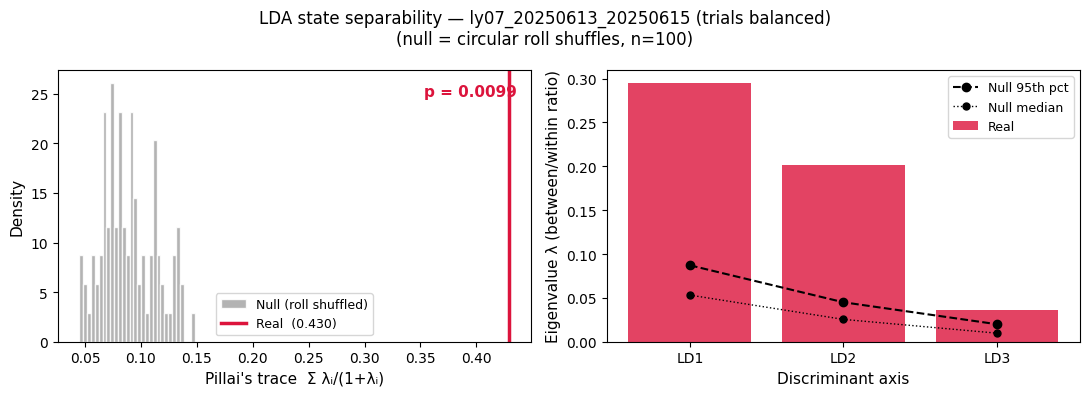

Pillai=0.4296, p=0.0099
Eigenvalues: [0.295 0.201 0.036]
ly07_20250616_20250617: 6 sessions, 88 neurons
  Balancing trials per task: keeping 11 per session (originally [11, 16, 41, 21, 24, 20])
  Real Pillai = 0.2689 | eigenvalues: [0.165 0.099 0.039]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


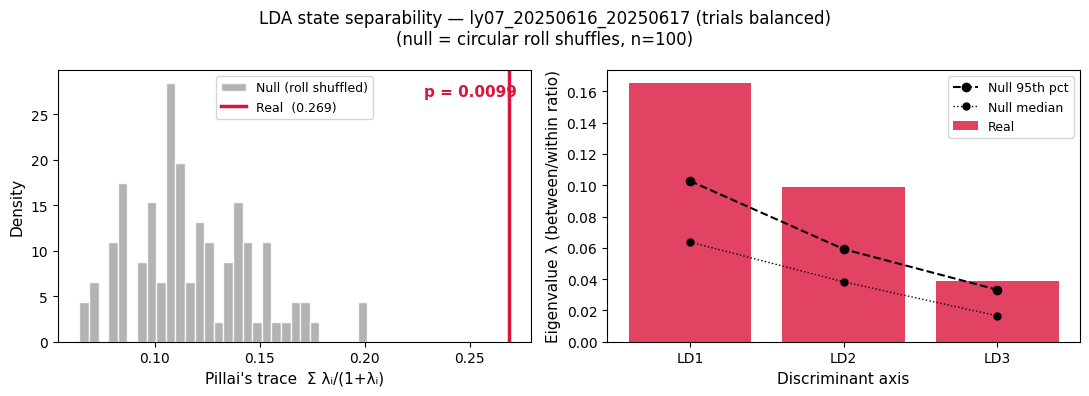

Pillai=0.2689, p=0.0099
Eigenvalues: [0.165 0.099 0.039]
ly07_20250618_20250619: 6 sessions, 88 neurons
  Balancing trials per task: keeping 12 per session (originally [12, 12, 27, 12, 17, 19])
  Real Pillai = 0.3187 | eigenvalues: [0.21  0.134 0.027]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


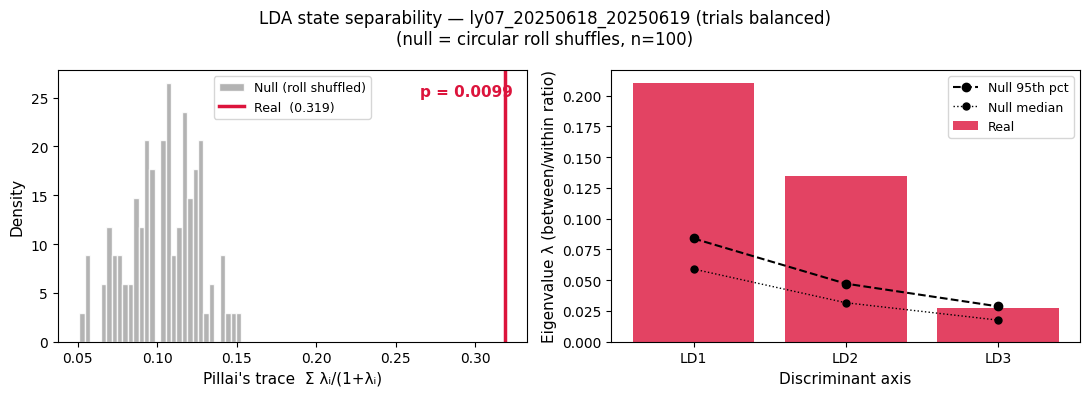

Pillai=0.3187, p=0.0099
Eigenvalues: [0.21  0.134 0.027]
ly07_20250620_20250623: 6 sessions, 89 neurons
  Balancing trials per task: keeping 15 per session (originally [26, 15, 32, 37, 53, 20])
  Real Pillai = 0.2120 | eigenvalues: [0.106 0.082 0.042]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


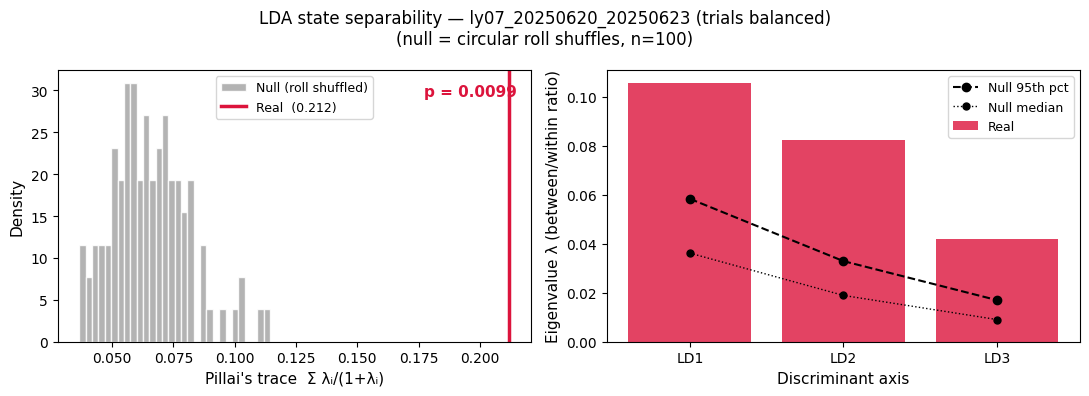

Pillai=0.2120, p=0.0099
Eigenvalues: [0.106 0.082 0.042]
ly07_20250624_20250625: 5 sessions, 86 neurons
  Balancing trials per task: keeping 10 per session (originally [24, 43, 10, 48, 36])
  Real Pillai = 0.8892 | eigenvalues: [0.669 0.549 0.155]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


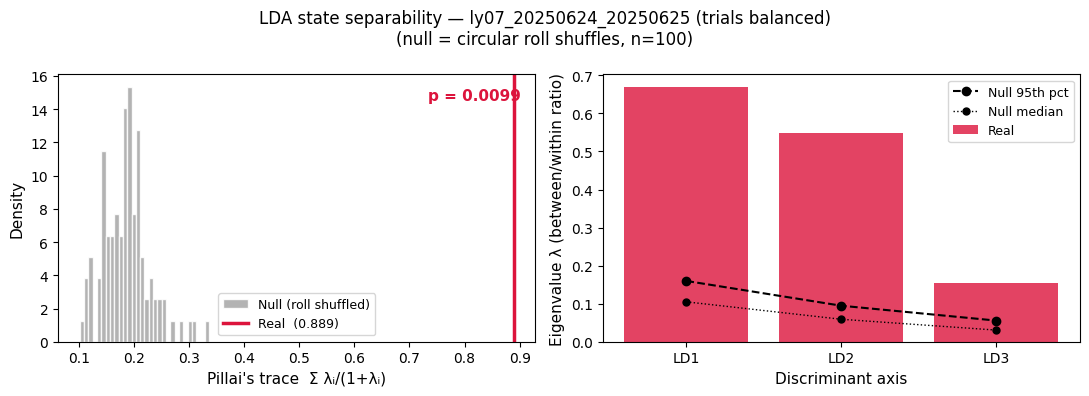

Pillai=0.8892, p=0.0099
Eigenvalues: [0.669 0.549 0.155]


In [59]:
from lda_state_analysis_trialbins import run_lda_eigenvalue_separation

for mouse_recday in mouse_recdays:
    sep = run_lda_eigenvalue_separation(
        data_dic, mouse_recday,
        valid_sessions=valid_sessions_dic[mouse_recday],
        neuron_subset=None,
        n_shuffles=100,
        balance_trials_per_task=True,
    )
    print(f"Pillai={sep['pillai']:.4f}, p={sep['p_value']:.4f}")
    print(f"Eigenvalues: {np.round(sep['eigenvalues'], 3)}")

### Controls for the Pillai-trace analysis

Three complementary tests of whether the large real-vs-null Pillai gap above reflects genuine **cross-task state tuning** vs an artefact of within-task similarity:

1. **T2 (within-task Pillai)** — fit LDA within each session separately and compare the average within-task Pillai to the across-task Pillai. If across-task ≫ within-task, pooling tasks adds signal. If similar, the across-task LDA is just averaging within-task structure.
2. **T1 (LOTO Pillai)** — fit LDA on N−1 sessions, project the held-out session's data through that fixed LDA, compute Pillai. Tests whether the LDA *direction* transfers across tasks.
3. **T3 (within-session shuffle null)** — stricter alternative null. Shuffles state labels within each session (preserving session structure, autocorrelation, and the actual extracted vectors) instead of rolling raw data. Conservative robustness check.

ah08_20250613_20250615: within-task Pillai over 6 sessions
  Session 0: Pillai=1.4981, p=0.0392
  Session 1: Pillai=1.8722, p=0.0196
  Session 2: Pillai=1.5474, p=0.0196
  Session 4: Pillai=2.1989, p=0.0196
  Session 5: Pillai=2.1097, p=0.0196
  Session 6: Pillai=1.8718, p=0.0196
ah08_20250613_20250615: mean within-task Pillai = 1.8497
ah08_20250616_20250617: within-task Pillai over 5 sessions
  Session 0: Pillai=2.1099, p=0.0196
  Session 1: Pillai=2.0756, p=0.0196
  Session 4: Pillai=2.1931, p=0.0196
  Session 5: Pillai=1.3848, p=0.0196
  Session 6: Pillai=2.1655, p=0.0196
ah08_20250616_20250617: mean within-task Pillai = 1.9858
ah08_20250618_20250619: within-task Pillai over 6 sessions
  Session 0: Pillai=2.2262, p=0.0196
  Session 1: Pillai=1.7493, p=0.0196
  Session 2: Pillai=2.5584, p=0.0196
  Session 4: Pillai=2.1730, p=0.0196
  Session 5: Pillai=1.5009, p=0.0196
  Session 6: Pillai=1.6961, p=0.0392
ah08_20250618_20250619: mean within-task Pillai = 1.9840
ah08_20250620_20250623:

  Session 0: Pillai=2.1267, p=0.0196
  Session 1: Pillai=2.3893, p=0.0196
  Session 2: Pillai=2.1730, p=0.0196
  Session 4: Pillai=2.4149, p=0.0196
  Session 5: Pillai=2.3423, p=0.0196
  Session 6: Pillai=2.0387, p=0.0196
ah10_20250613_20250615: mean within-task Pillai = 2.2475
ah10_20250616_20250617: within-task Pillai over 6 sessions
  Session 0: Pillai=2.3299, p=0.0196
  Session 1: Pillai=2.6221, p=0.0196
  Session 2: Pillai=2.1598, p=0.0196
  Session 4: Pillai=2.1417, p=0.0196
  Session 5: Pillai=1.9790, p=0.0196
  Session 6: Pillai=2.1630, p=0.0196
ah10_20250616_20250617: mean within-task Pillai = 2.2326
ah10_20250618_20250619: within-task Pillai over 6 sessions
  Session 0: Pillai=1.8340, p=0.0196
  Session 1: Pillai=2.3664, p=0.0196
  Session 2: Pillai=2.2772, p=0.0196
  Session 4: Pillai=2.2273, p=0.0196
  Session 5: Pillai=2.3464, p=0.0196
  Session 6: Pillai=2.6407, p=0.0196
ah10_20250618_20250619: mean within-task Pillai = 2.2820
ah10_20250620_20250623: within-task Pillai ov

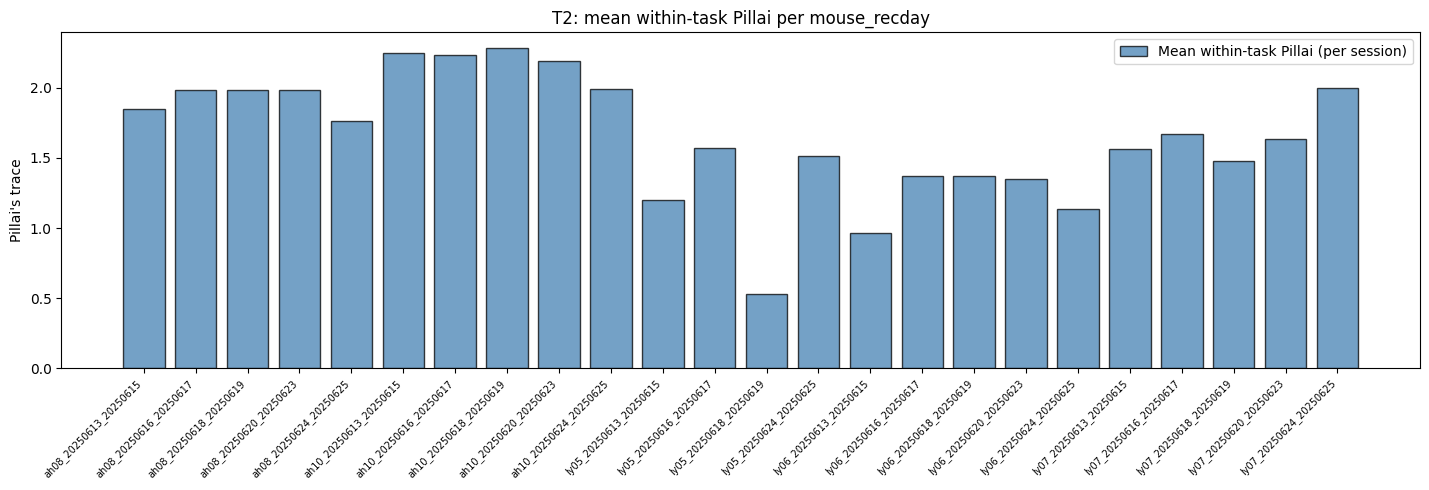

Mean within-task Pillai per mouse_recday:
  ah08_20250613_20250615: μ=1.8497  (per-session: [1.498, 1.872, 1.547, 2.199, 2.11, 1.872])
  ah08_20250616_20250617: μ=1.9858  (per-session: [2.11, 2.076, 2.193, 1.385, 2.165])
  ah08_20250618_20250619: μ=1.9840  (per-session: [2.226, 1.749, 2.558, 2.173, 1.501, 1.696])
  ah08_20250620_20250623: μ=1.9871  (per-session: [2.023, 2.119, 2.522, 1.31, 1.962])
  ah08_20250624_20250625: μ=1.7603  (per-session: [2.142, 1.565, 1.587, 1.747])
  ah10_20250613_20250615: μ=2.2475  (per-session: [2.127, 2.389, 2.173, 2.415, 2.342, 2.039])
  ah10_20250616_20250617: μ=2.2326  (per-session: [2.33, 2.622, 2.16, 2.142, 1.979, 2.163])
  ah10_20250618_20250619: μ=2.2820  (per-session: [1.834, 2.366, 2.277, 2.227, 2.346, 2.641])
  ah10_20250620_20250623: μ=2.1949  (per-session: [2.164, 2.007, 2.412, 2.177, 1.962, 2.448])
  ah10_20250624_20250625: μ=1.9918  (per-session: [1.912, 2.389, 1.756, 1.823, 1.836, 2.234])
  ly05_20250613_20250615: μ=1.2013  (per-session: [

In [60]:
# T2: within-task Pillai trace per session.
# Compare mean within-task Pillai to the across-task Pillai (`sep['pillai']` from cell above).

import lda_state_analysis_trialbins
reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import run_within_task_pillai

within_task_results = {}
across_task_pillais = {}  # mr -> across-task Pillai (one run of the original analysis)

for mr in mouse_recdays:
    try:
        within_task_results[mr] = run_within_task_pillai(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            n_shuffles=50,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')

# Per-mouse_recday: mean within-task Pillai vs across-task Pillai
recdays_sorted = sorted(within_task_results.keys())
fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(recdays_sorted)), 5))
x = np.arange(len(recdays_sorted))
within_means = [within_task_results[mr]['mean_within_task_pillai'] for mr in recdays_sorted]
ax.bar(x, within_means, color='steelblue', alpha=0.75, edgecolor='black',
       label='Mean within-task Pillai (per session)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(recdays_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("Pillai's trace")
ax.set_title('T2: mean within-task Pillai per mouse_recday')
ax.legend()
plt.tight_layout()
plt.show()

# Printed summary
print('Mean within-task Pillai per mouse_recday:')
for mr in recdays_sorted:
    r = within_task_results[mr]
    per_sess = r['per_session_pillais']
    valid = ~np.isnan(per_sess)
    print(f"  {mr}: \u03bc={r['mean_within_task_pillai']:.4f}  "
          f"(per-session: {np.round(per_sess[valid], 3).tolist()})")

Task is [3 2 7 1]
Task is [3 4 6 7]
Task is [7 5 1 6]
Task is [6 4 9 2]
Task is [7 9 5 4]
Task is [7 3 1 5]
ah08_20250613_20250615: 6 sessions, 151 neurons
  Session 0 (index 0): 5 trials, T=45293 samples
  Session 1 (index 1): 9 trials, T=46043 samples
  Session 2 (index 2): 7 trials, T=40895 samples
  Session 4 (index 3): 11 trials, T=46785 samples
  Session 5 (index 4): 21 trials, T=48367 samples
  Session 6 (index 5): 10 trials, T=45850 samples
(array([0, 1, 2, 3, 4, 5]), array([20, 36, 28, 44, 84, 40]))
  Dataset: 252 samples (0 skipped) from 252 (trial, state) pairs
ah08_20250613_20250615: LOTO over 6 sessions


  Fold 1/6 (held-out s=0): Pillai=2.3636, p=0.1569
  Fold 2/6 (held-out s=1): Pillai=2.5888, p=0.0196
  Fold 3/6 (held-out s=2): Pillai=2.7148, p=0.1961
  Fold 4/6 (held-out s=3): Pillai=2.4287, p=0.0196
  Fold 5/6 (held-out s=4): Pillai=2.0262, p=0.0196
  Fold 6/6 (held-out s=5): Pillai=2.4982, p=0.0196
ah08_20250613_20250615: mean LOTO Pillai = 2.4367
Task is [8 2 9 5]
Task is [5 2 7 8]
Task is [9 1 6 4]
Task is [7 8 3 6]
Task is [4 6 3 9]
ah08_20250616_20250617: 5 sessions, 164 neurons
  Session 0 (index 0): 15 trials, T=43652 samples
  Session 1 (index 1): 13 trials, T=47013 samples
  Session 4 (index 2): 16 trials, T=43713 samples
  Session 5 (index 3): 15 trials, T=47334 samples
  Session 6 (index 4): 14 trials, T=45211 samples
(array([0, 1, 2, 3, 4]), array([60, 52, 64, 60, 56]))
  Dataset: 292 samples (0 skipped) from 292 (trial, state) pairs
ah08_20250616_20250617: LOTO over 5 sessions
  Fold 1/5 (held-out s=0): Pillai=2.1180, p=0.0196
  Fold 2/5 (held-out s=1): Pillai=2.4384,

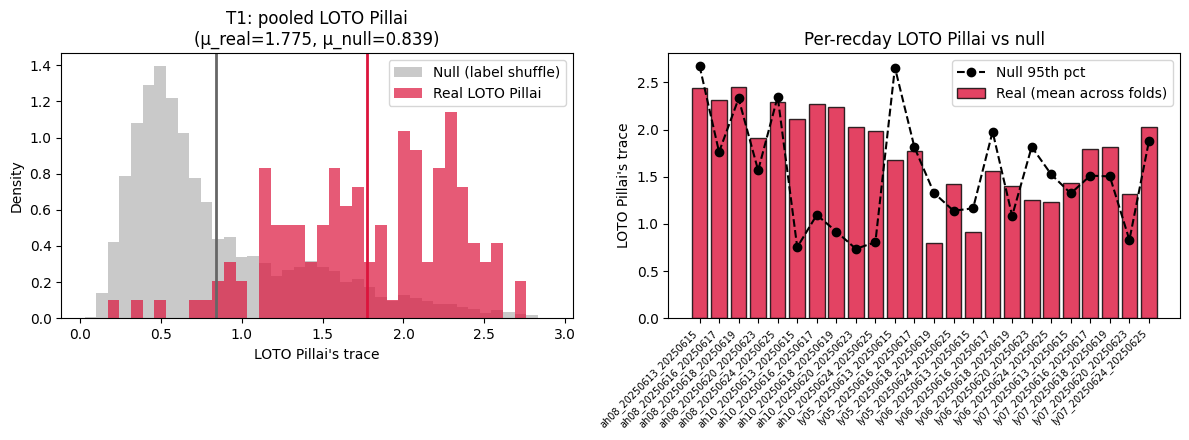

In [61]:
# T1: leave-one-task-out Pillai trace.
# For each held-out session, fit LDA on the rest; project held-out through it; compute Pillai.
# Tests whether the LDA direction generalises across tasks.

import lda_state_analysis_trialbins
reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import run_lda_eigenvalue_separation_loto

loto_results = {}
for mr in mouse_recdays:
    try:
        loto_results[mr] = run_lda_eigenvalue_separation_loto(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            n_shuffles=50,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')

# Pool LOTO Pillai across mouse_recdays
recdays_sorted = sorted(loto_results.keys())
all_real = np.concatenate([loto_results[mr]['loto_pillais'] for mr in recdays_sorted])
all_real = all_real[~np.isnan(all_real)]
all_null = np.concatenate([loto_results[mr]['null_loto_pillais'].ravel() for mr in recdays_sorted])
all_null = all_null[~np.isnan(all_null)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: pooled real vs null distribution
ax = axes[0]
bins = np.linspace(
    min(all_null.min(), all_real.min()) - 0.05,
    max(all_null.max(), all_real.max()) + 0.05, 41)
ax.hist(all_null, bins=bins, color='0.7', alpha=0.7, density=True, label='Null (label shuffle)')
ax.hist(all_real, bins=bins, color='crimson', alpha=0.7, density=True, label='Real LOTO Pillai')
ax.axvline(all_real.mean(), color='crimson', linewidth=2)
ax.axvline(all_null.mean(), color='0.4', linewidth=2)
ax.set_xlabel("LOTO Pillai's trace")
ax.set_ylabel('Density')
ax.set_title(f'T1: pooled LOTO Pillai\n(\u03bc_real={all_real.mean():.3f}, \u03bc_null={all_null.mean():.3f})')
ax.legend()

# Panel 2: per-mouse_recday mean LOTO Pillai vs null 95th pct
ax = axes[1]
x = np.arange(len(recdays_sorted))
mean_real = [np.nanmean(loto_results[mr]['loto_pillais']) for mr in recdays_sorted]
null_95 = [np.nanpercentile(loto_results[mr]['null_loto_pillais'], 95) for mr in recdays_sorted]
ax.bar(x, mean_real, color='crimson', alpha=0.8, edgecolor='black', label='Real (mean across folds)')
ax.plot(x, null_95, 'ko--', label='Null 95th pct')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(recdays_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("LOTO Pillai's trace")
ax.set_title('Per-recday LOTO Pillai vs null')
ax.legend()
plt.tight_layout()
plt.show()

Task is [3 2 7 1]
Task is [3 4 6 7]
Task is [7 5 1 6]
Task is [6 4 9 2]
Task is [7 9 5 4]
Task is [7 3 1 5]
ah08_20250613_20250615: 6 sessions, 151 neurons
  Session 0 (index 0): 5 trials, T=45293 samples
  Session 1 (index 1): 9 trials, T=46043 samples
  Session 2 (index 2): 7 trials, T=40895 samples
  Session 4 (index 3): 11 trials, T=46785 samples
  Session 5 (index 4): 21 trials, T=48367 samples
  Session 6 (index 5): 10 trials, T=45850 samples
(array([0, 1, 2, 3, 4, 5]), array([20, 36, 28, 44, 84, 40]))
  Dataset: 252 samples (0 skipped) from 252 (trial, state) pairs
ah08_20250613_20250615: real Pillai = 0.7824  (within-session shuffle null)
  Shuffle 20/100 done
  Shuffle 40/100 done
  Shuffle 60/100 done
  Shuffle 80/100 done
  Shuffle 100/100 done
  p = 0.0099 (n_valid_shuffles = 100)
Task is [8 2 9 5]
Task is [5 2 7 8]
Task is [9 1 6 4]
Task is [7 8 3 6]
Task is [4 6 3 9]
ah08_20250616_20250617: 5 sessions, 164 neurons


  Session 0 (index 0): 15 trials, T=43652 samples
  Session 1 (index 1): 13 trials, T=47013 samples
  Session 4 (index 2): 16 trials, T=43713 samples
  Session 5 (index 3): 15 trials, T=47334 samples
  Session 6 (index 4): 14 trials, T=45211 samples
(array([0, 1, 2, 3, 4]), array([60, 52, 64, 60, 56]))
  Dataset: 292 samples (0 skipped) from 292 (trial, state) pairs
ah08_20250616_20250617: real Pillai = 0.9351  (within-session shuffle null)
  Shuffle 20/100 done
  Shuffle 40/100 done
  Shuffle 60/100 done
  Shuffle 80/100 done
  Shuffle 100/100 done
  p = 0.0099 (n_valid_shuffles = 100)
Task is [3 1 4 2]
Task is [6 3 4 5]
Task is [5 4 1 6]
Task is [6 5 8 1]
Task is [1 5 2 4]
Task is [2 7 9 5]
ah08_20250618_20250619: 6 sessions, 183 neurons
  Session 0 (index 0): 22 trials, T=48447 samples
  Session 1 (index 1): 15 trials, T=47622 samples
  Session 2 (index 2): 21 trials, T=48500 samples
  Session 4 (index 3): 23 trials, T=54879 samples
  Session 5 (index 4): 11 trials, T=45841 samples


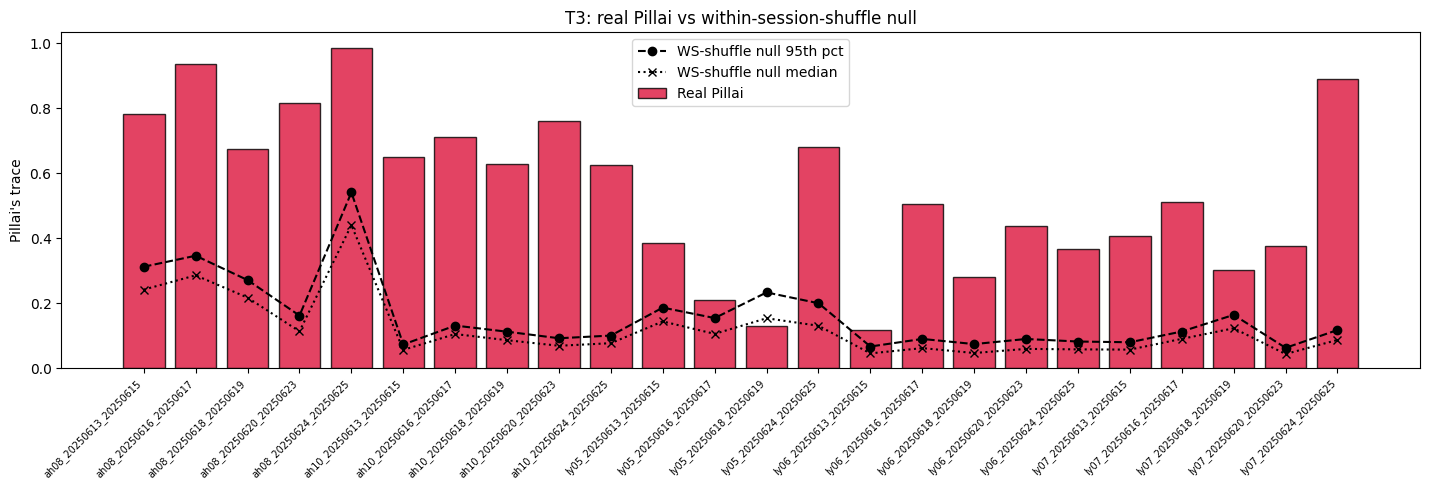

Per-recday p-values under within-session shuffle null:
  ah08_20250613_20250615: Pillai=0.7824, p=0.0099
  ah08_20250616_20250617: Pillai=0.9351, p=0.0099
  ah08_20250618_20250619: Pillai=0.6731, p=0.0099
  ah08_20250620_20250623: Pillai=0.8171, p=0.0099
  ah08_20250624_20250625: Pillai=0.9842, p=0.0099
  ah10_20250613_20250615: Pillai=0.6501, p=0.0099
  ah10_20250616_20250617: Pillai=0.7103, p=0.0099
  ah10_20250618_20250619: Pillai=0.6284, p=0.0099
  ah10_20250620_20250623: Pillai=0.7608, p=0.0099
  ah10_20250624_20250625: Pillai=0.6255, p=0.0099
  ly05_20250613_20250615: Pillai=0.3859, p=0.0099
  ly05_20250616_20250617: Pillai=0.2091, p=0.0099
  ly05_20250618_20250619: Pillai=0.1297, p=0.7822
  ly05_20250624_20250625: Pillai=0.6818, p=0.0099
  ly06_20250613_20250615: Pillai=0.1167, p=0.0099
  ly06_20250616_20250617: Pillai=0.5060, p=0.0099
  ly06_20250618_20250619: Pillai=0.2822, p=0.0099
  ly06_20250620_20250623: Pillai=0.4376, p=0.0099
  ly06_20250624_20250625: Pillai=0.3669, p=0.

In [62]:
# T3: within-session label-shuffle null.
# Stricter alternative null. Shuffles state labels within each session, preserving
# the actual extracted vectors and within-session structure. Compare to the
# existing roll-shuffle null.

import lda_state_analysis_trialbins
reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import run_within_session_shuffle_null

ws_null_results = {}
for mr in mouse_recdays:
    try:
        ws_null_results[mr] = run_within_session_shuffle_null(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            n_shuffles=100,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')

# Per-recday: real Pillai vs within-session-shuffle null 95th pct
recdays_sorted = sorted(ws_null_results.keys())
fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(recdays_sorted)), 5))
x = np.arange(len(recdays_sorted))
real_p = [ws_null_results[mr]['pillai'] for mr in recdays_sorted]
null_95 = [np.nanpercentile(ws_null_results[mr]['null_pillais'], 95) for mr in recdays_sorted]
null_50 = [np.nanpercentile(ws_null_results[mr]['null_pillais'], 50) for mr in recdays_sorted]
ax.bar(x, real_p, color='crimson', alpha=0.8, edgecolor='black', label='Real Pillai')
ax.plot(x, null_95, 'ko--', label='WS-shuffle null 95th pct')
ax.plot(x, null_50, 'kx:',  label='WS-shuffle null median')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(recdays_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("Pillai's trace")
ax.set_title('T3: real Pillai vs within-session-shuffle null')
ax.legend()
plt.tight_layout()
plt.show()

# Printed p-values per recday
print('Per-recday p-values under within-session shuffle null:')
for mr in recdays_sorted:
    r = ws_null_results[mr]
    print(f"  {mr}: Pillai={r['pillai']:.4f}, p={r['p_value']:.4f}")

## Pseudotime-matched state correlation (drift control)

For each pair of sessions and each *shared trial number*, correlate the population vector of state X in task 1 with that of state Y in task 2. Matching by trial number controls for slow drift in firing rates — paired trials sit at roughly the same point in the recording timeline, so drift affects both similarly. We then bucket the resulting correlations by whether the states match (within-state: X=Y) or differ (across-state: X≠Y).

**Prediction**: if neurons carry state information beyond drift, **within-state correlations exceed across-state correlations**. The two-sample t-test in the right panel quantifies the gap; the per-recday paired test reported at the bottom is more conservative (treats each recording as a single observation).

Uses `build_trialbins_dataset` + `compute_pseudotime_state_correlations` from `lda_state_analysis_trialbins.py`.

Task is [3 2 7 1]
Task is [3 4 6 7]
Task is [7 5 1 6]
Task is [6 4 9 2]
Task is [7 9 5 4]
Task is [7 3 1 5]
ah08_20250613_20250615: 6 sessions, 151 neurons
  Session 0 (index 0): 5 trials, T=45293 samples
  Session 1 (index 1): 9 trials, T=46043 samples
  Session 2 (index 2): 7 trials, T=40895 samples
  Session 4 (index 3): 11 trials, T=46785 samples
  Session 5 (index 4): 21 trials, T=48367 samples
  Session 6 (index 5): 10 trials, T=45850 samples
(array([0, 1, 2, 3, 4, 5]), array([20, 36, 28, 44, 84, 40]))
  Dataset: 252 samples (0 skipped) from 252 (trial, state) pairs
  ah08_20250613_20250615: within μ=0.053 (n=444)  across μ=0.054 (n=1332)
Task is [8 2 9 5]
Task is [5 2 7 8]
Task is [9 1 6 4]
Task is [7 8 3 6]
Task is [4 6 3 9]
ah08_20250616_20250617: 5 sessions, 164 neurons
  Session 0 (index 0): 15 trials, T=43652 samples
  Session 1 (index 1): 13 trials, T=47013 samples
  Session 4 (index 2): 16 trials, T=43713 samples
  Session 5 (index 3): 15 trials, T=47334 samples
  Session

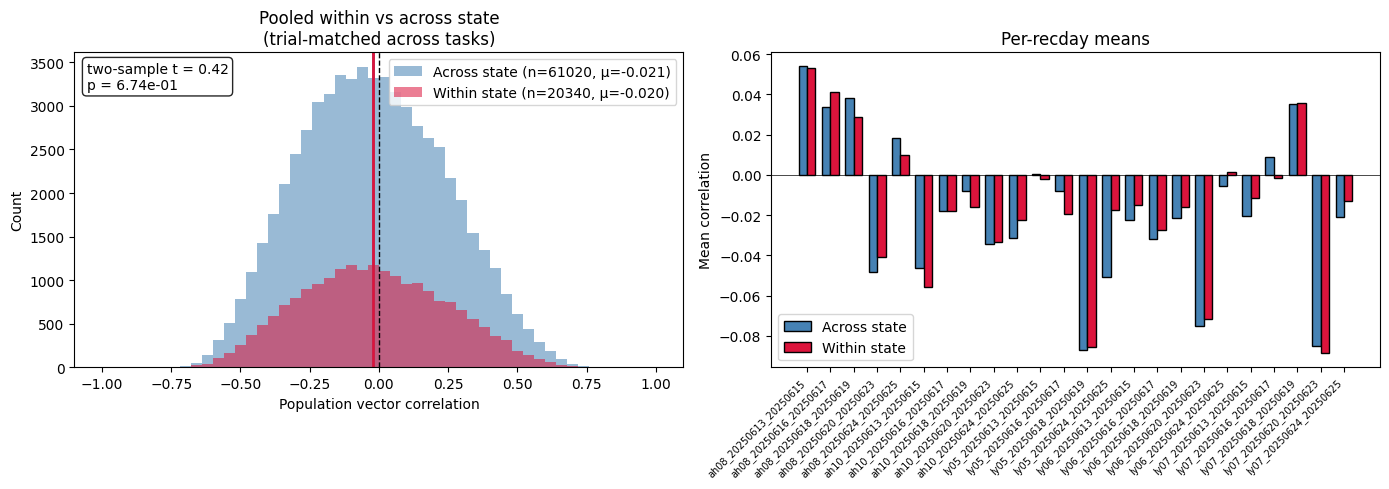


Per-recday paired test (within - across): mean Δ=0.0017, t=0.89, p=3.85e-01


In [63]:
# Pseudotime-matched state correlation across mouse_recdays.
# For each (session_pair, shared trial number, state_a, state_b): correlate the
# two population vectors. Within-state pairs (state_a == state_b) should exceed
# across-state pairs if state tuning isn't explained by global drift.

reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import (
    build_trialbins_dataset,
    compute_pseudotime_state_correlations,
    EVENT_LABELS,
)

pooled_within = []
pooled_across = []
per_recday = {}  # mouse_recday -> (mean_within, mean_across, n_within, n_across)
per_recday_arrays = {}  # mouse_recday -> (within_arr, across_arr) for downstream grouping

for mr in mouse_recdays:
    try:
        X, y_state, sess_id, trial_id, _, _ = build_trialbins_dataset(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            neuron_subset=None,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')
        continue

    within, across = compute_pseudotime_state_correlations(X, y_state, sess_id, trial_id)
    if not within or not across:
        print(f'  {mr}: no comparable pairs, skipped')
        continue

    w = np.array([d['corr'] for d in within])
    a = np.array([d['corr'] for d in across])
    pooled_within.append(w)
    pooled_across.append(a)
    per_recday[mr] = (w.mean(), a.mean(), len(w), len(a))
    per_recday_arrays[mr] = (w, a)
    print(f"  {mr}: within \u03bc={w.mean():.3f} (n={len(w)})  across \u03bc={a.mean():.3f} (n={len(a)})")

pooled_within = np.concatenate(pooled_within)
pooled_across = np.concatenate(pooled_across)

# --- Cross-mouse summary figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(-1, 1, 51)
ax.hist(pooled_across, bins=bins, color='steelblue', alpha=0.55,
        label=f'Across state (n={len(pooled_across)}, \u03bc={pooled_across.mean():.3f})')
ax.hist(pooled_within, bins=bins, color='crimson', alpha=0.55,
        label=f'Within state (n={len(pooled_within)}, \u03bc={pooled_within.mean():.3f})')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(pooled_across.mean(), color='steelblue', linewidth=2)
ax.axvline(pooled_within.mean(), color='crimson', linewidth=2)
t_stat, p_val = st.ttest_ind(pooled_within, pooled_across)
ax.text(0.02, 0.97, f'two-sample t = {t_stat:.2f}\np = {p_val:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.set_xlabel('Population vector correlation')
ax.set_ylabel('Count')
ax.set_title('Pooled within vs across state\n(trial-matched across tasks)')
ax.legend(loc='upper right')

ax = axes[1]
recdays_sorted = sorted(per_recday.keys())
w_means = [per_recday[mr][0] for mr in recdays_sorted]
a_means = [per_recday[mr][1] for mr in recdays_sorted]
x = np.arange(len(recdays_sorted))
ax.bar(x - 0.18, a_means, width=0.36, color='steelblue', label='Across state', edgecolor='black')
ax.bar(x + 0.18, w_means, width=0.36, color='crimson', label='Within state', edgecolor='black')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(recdays_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Mean correlation')
ax.set_title('Per-recday means')
ax.legend()

plt.tight_layout()
plt.show()

# Paired test at the recday level (more conservative than pooling)
diffs = np.array(w_means) - np.array(a_means)
t_paired, p_paired = st.ttest_1samp(diffs, 0)
print(f"\nPer-recday paired test (within - across): "
      f"mean \u0394={diffs.mean():.4f}, t={t_paired:.2f}, p={p_paired:.2e}")

### Per-mouse breakdown

Aggregate within/across-state correlations by **mouse identity** (the first underscore-separated token of `mouse_recday`, e.g. `ah08`). Concatenates all of a mouse's recdays and produces (a) a histogram grid (one per mouse, overlaying within vs across) and (b) a bar chart of per-mouse means.

Per-mouse paired test (treats each mouse as one observation of `within − across` averaged across its recdays) is the most conservative inference at this granularity.

  ah08: 5 recdays, within μ=0.017 (n=2548)  across μ=0.017 (n=7644)
  ah10: 5 recdays, within μ=-0.029 (n=7304)  across μ=-0.028 (n=21912)
  ly05: 4 recdays, within μ=-0.022 (n=1324)  across μ=-0.023 (n=3972)
  ly06: 5 recdays, within μ=-0.021 (n=4004)  across μ=-0.027 (n=12012)
  ly07: 5 recdays, within μ=-0.023 (n=5160)  across μ=-0.023 (n=15480)


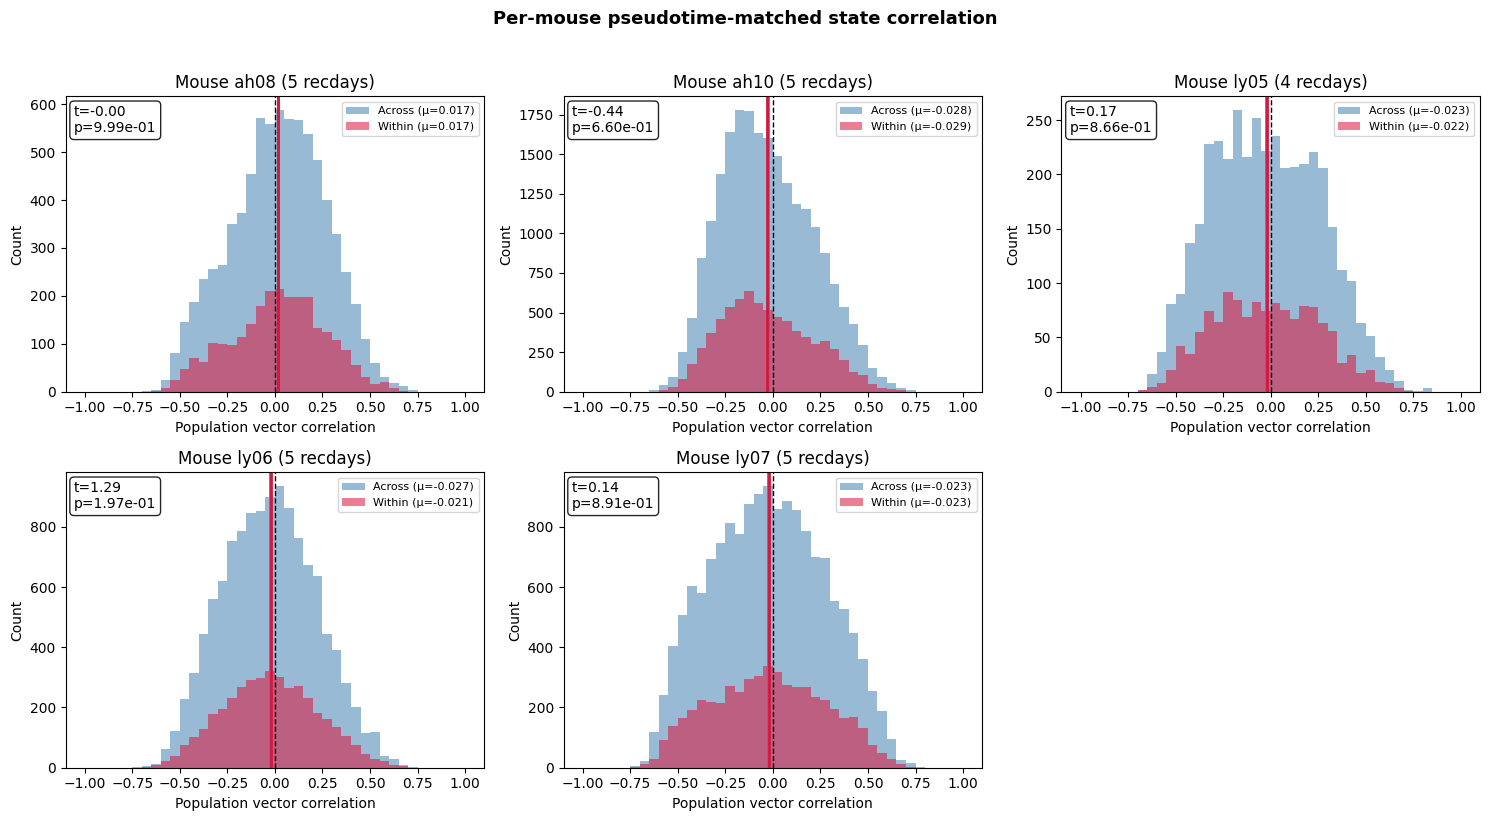

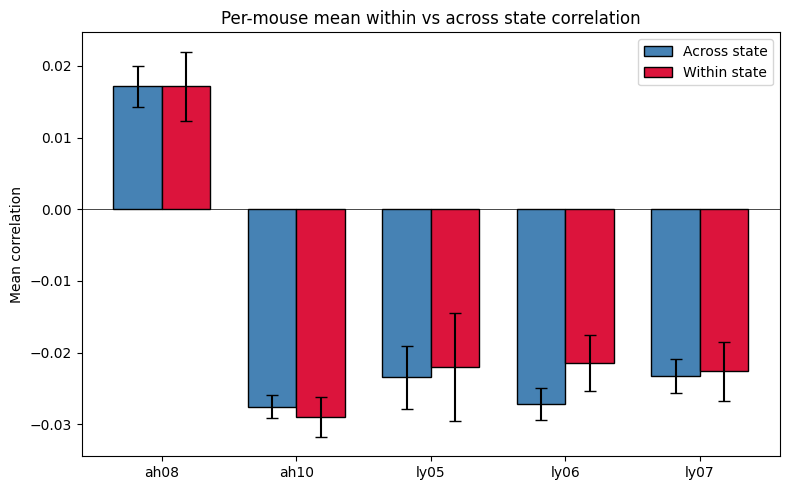


Per-mouse paired test (within - across): mean Δ=0.0013, t=1.07, p=3.46e-01  (n_mice=5)


In [64]:
# Per-mouse aggregation of pseudotime correlations.
from collections import defaultdict

# Group recdays by mouse identity (first '_' token of mouse_recday)
mouse_to_recdays = defaultdict(list)
for mr in per_recday_arrays:
    mouse = mr.split('_')[0]
    mouse_to_recdays[mouse].append(mr)

mice_sorted = sorted(mouse_to_recdays.keys())

# Concatenate within/across arrays per mouse
by_mouse = {}
for mouse in mice_sorted:
    w_all = np.concatenate([per_recday_arrays[mr][0] for mr in mouse_to_recdays[mouse]])
    a_all = np.concatenate([per_recday_arrays[mr][1] for mr in mouse_to_recdays[mouse]])
    by_mouse[mouse] = (w_all, a_all)
    print(f'  {mouse}: {len(mouse_to_recdays[mouse])} recdays, '
          f'within \u03bc={w_all.mean():.3f} (n={len(w_all)})  '
          f'across \u03bc={a_all.mean():.3f} (n={len(a_all)})')

# --- Figure 1: histogram grid (one panel per mouse) ---
n_mice = len(mice_sorted)
ncols = min(n_mice, 3)
nrows = (n_mice + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
bins = np.linspace(-1, 1, 41)
for i, mouse in enumerate(mice_sorted):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    w_arr, a_arr = by_mouse[mouse]
    ax.hist(a_arr, bins=bins, color='steelblue', alpha=0.55,
            label=f'Across (\u03bc={a_arr.mean():.3f})')
    ax.hist(w_arr, bins=bins, color='crimson', alpha=0.55,
            label=f'Within (\u03bc={w_arr.mean():.3f})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(a_arr.mean(), color='steelblue', linewidth=2)
    ax.axvline(w_arr.mean(), color='crimson', linewidth=2)
    t, p = st.ttest_ind(w_arr, a_arr)
    ax.text(0.02, 0.97, f't={t:.2f}\np={p:.2e}',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_title(f'Mouse {mouse} ({len(mouse_to_recdays[mouse])} recdays)')
    ax.set_xlabel('Population vector correlation')
    ax.set_ylabel('Count')
    ax.legend(loc='upper right', fontsize=8)
# Hide any unused axes
for j in range(n_mice, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis('off')
plt.suptitle('Per-mouse pseudotime-matched state correlation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: per-mouse bar chart of within/across means ---
fig, ax = plt.subplots(figsize=(8, 5))
w_mouse_means = [by_mouse[m][0].mean() for m in mice_sorted]
a_mouse_means = [by_mouse[m][1].mean() for m in mice_sorted]
w_mouse_sems = [by_mouse[m][0].std() / np.sqrt(len(by_mouse[m][0])) for m in mice_sorted]
a_mouse_sems = [by_mouse[m][1].std() / np.sqrt(len(by_mouse[m][1])) for m in mice_sorted]
x = np.arange(len(mice_sorted))
ax.bar(x - 0.18, a_mouse_means, yerr=a_mouse_sems, width=0.36,
       color='steelblue', label='Across state', edgecolor='black', capsize=4)
ax.bar(x + 0.18, w_mouse_means, yerr=w_mouse_sems, width=0.36,
       color='crimson', label='Within state', edgecolor='black', capsize=4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(mice_sorted)
ax.set_ylabel('Mean correlation')
ax.set_title('Per-mouse mean within vs across state correlation')
ax.legend()
plt.tight_layout()
plt.show()

# --- Per-mouse paired test (most conservative; one observation per mouse) ---
mouse_diffs = np.array(w_mouse_means) - np.array(a_mouse_means)
if len(mouse_diffs) >= 2:
    t_m, p_m = st.ttest_1samp(mouse_diffs, 0)
    print(f'\nPer-mouse paired test (within - across): '
          f'mean \u0394={mouse_diffs.mean():.4f}, t={t_m:.2f}, p={p_m:.2e}  (n_mice={len(mouse_diffs)})')
else:
    print(f'\nOnly {len(mouse_diffs)} mouse(s); paired test not meaningful.')

#### Aggregator: mean vs max per state window

The pseudotime analysis above used **mean** firing across each state window for the per-(trial, state) population vectors. The cell below reruns the cross-task analysis with **max** instead — useful when state-tuning is transient/punctate rather than sustained. Side-by-side comparison of pooled within vs across distributions under both aggregators.

Task is [3 2 7 1]
Task is [3 4 6 7]
Task is [7 5 1 6]
Task is [6 4 9 2]
Task is [7 9 5 4]
Task is [7 3 1 5]
ah08_20250613_20250615: 6 sessions, 151 neurons
  Session 0 (index 0): 5 trials, T=45293 samples
  Session 1 (index 1): 9 trials, T=46043 samples
  Session 2 (index 2): 7 trials, T=40895 samples
  Session 4 (index 3): 11 trials, T=46785 samples
  Session 5 (index 4): 21 trials, T=48367 samples
  Session 6 (index 5): 10 trials, T=45850 samples
(array([0, 1, 2, 3, 4, 5]), array([20, 36, 28, 44, 84, 40]))
  Dataset: 252 samples (0 skipped) from 252 (trial, state) pairs
Task is [8 2 9 5]
Task is [5 2 7 8]
Task is [9 1 6 4]
Task is [7 8 3 6]
Task is [4 6 3 9]
ah08_20250616_20250617: 5 sessions, 164 neurons
  Session 0 (index 0): 15 trials, T=43652 samples
  Session 1 (index 1): 13 trials, T=47013 samples
  Session 4 (index 2): 16 trials, T=43713 samples
  Session 5 (index 3): 15 trials, T=47334 samples
  Session 6 (index 4): 14 trials, T=45211 samples
(array([0, 1, 2, 3, 4]), array([6

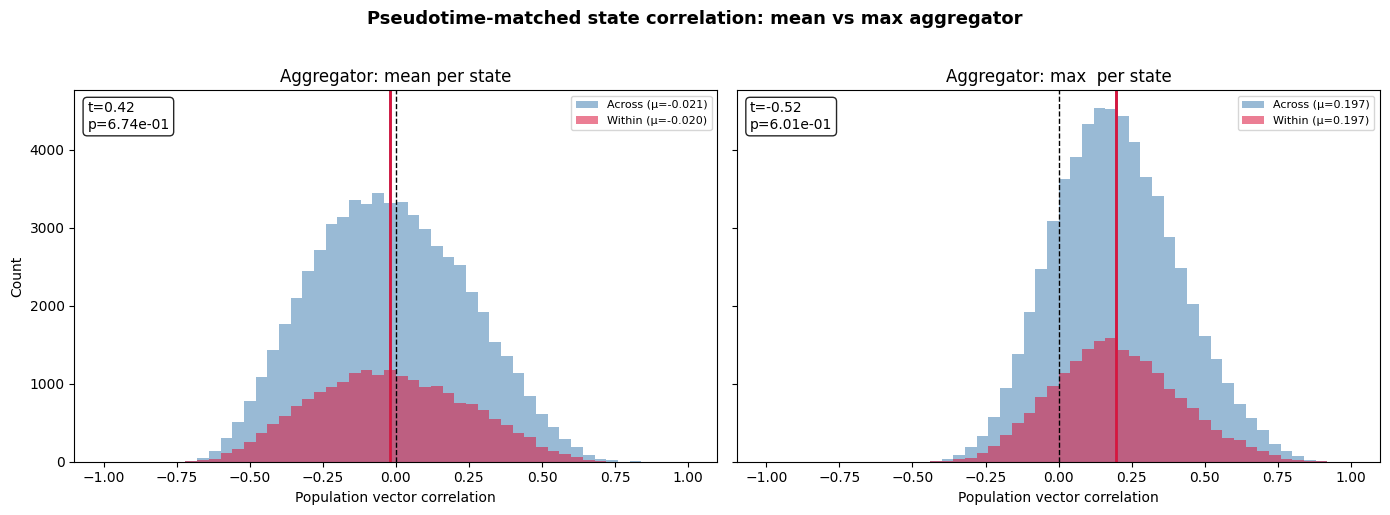

In [65]:
# Pseudotime-matched correlation with MAX aggregation per state (vs the MEAN above).
# Uses build_trialbins_dataset(..., aggregator='max').

reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import (
    build_trialbins_dataset,
    compute_pseudotime_state_correlations,
)

pooled_within_max = []
pooled_across_max = []
for mr in mouse_recdays:
    try:
        X, y_state, sess_id, trial_id, _, _ = build_trialbins_dataset(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            neuron_subset=None,
            aggregator='max',
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')
        continue
    within, across = compute_pseudotime_state_correlations(X, y_state, sess_id, trial_id)
    if within and across:
        pooled_within_max.append(np.array([d['corr'] for d in within]))
        pooled_across_max.append(np.array([d['corr'] for d in across]))

pooled_within_max = np.concatenate(pooled_within_max)
pooled_across_max = np.concatenate(pooled_across_max)

# Side-by-side: mean (re-uses pooled_within / pooled_across from cell 14) vs max
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
bins = np.linspace(-1, 1, 51)
for ax, (lbl, w, a) in zip(axes, [
        ('mean per state', pooled_within, pooled_across),
        ('max  per state', pooled_within_max, pooled_across_max)]):
    ax.hist(a, bins=bins, color='steelblue', alpha=0.55,
            label=f'Across (\u03bc={a.mean():.3f})')
    ax.hist(w, bins=bins, color='crimson', alpha=0.55,
            label=f'Within (\u03bc={w.mean():.3f})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(a.mean(), color='steelblue', linewidth=2)
    ax.axvline(w.mean(), color='crimson', linewidth=2)
    t, p = st.ttest_ind(w, a)
    ax.text(0.02, 0.97, f't={t:.2f}\np={p:.2e}',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_xlabel('Population vector correlation')
    ax.set_title(f'Aggregator: {lbl}')
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('Pseudotime-matched state correlation: mean vs max aggregator',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Per goal-progress bin breakdown (early / middle / late)

Split each state's 90-bin window into 3 equal sub-windows (goal-progress bins). Rerun the pseudotime-matched within-vs-across-state correlation analysis separately within each gp bin. Tests whether the within > across pattern holds across all phases of goal progress (early/middle/late within each state), or is concentrated at a particular phase (e.g., reward approach).

Uses `build_trialbins_gp_dataset` from `lda_state_analysis_trialbins.py`, which extracts one population vector per (trial, state, gp_bin). The cell below filters by gp bin and reuses `compute_pseudotime_state_correlations` for the within/across correlation logic.

  GP dataset: 756 samples (0 skipped); 3 gp bins per state
  GP dataset: 876 samples (0 skipped); 3 gp bins per state
  GP dataset: 1188 samples (0 skipped); 3 gp bins per state
  GP dataset: 1140 samples (0 skipped); 3 gp bins per state
  GP dataset: 432 samples (0 skipped); 3 gp bins per state
  GP dataset: 2076 samples (0 skipped); 3 gp bins per state
  GP dataset: 1716 samples (0 skipped); 3 gp bins per state
  GP dataset: 2040 samples (0 skipped); 3 gp bins per state
  GP dataset: 2208 samples (0 skipped); 3 gp bins per state
  GP dataset: 1992 samples (0 skipped); 3 gp bins per state
  GP dataset: 912 samples (0 skipped); 3 gp bins per state
  GP dataset: 900 samples (0 skipped); 3 gp bins per state
  GP dataset: 420 samples (0 skipped); 3 gp bins per state
  GP dataset: 648 samples (0 skipped); 3 gp bins per state
  GP dataset: 1428 samples (0 skipped); 3 gp bins per state
  GP dataset: 1308 samples (0 skipped); 3 gp bins per state
  GP dataset: 1284 samples (0 skipped); 3 gp bi

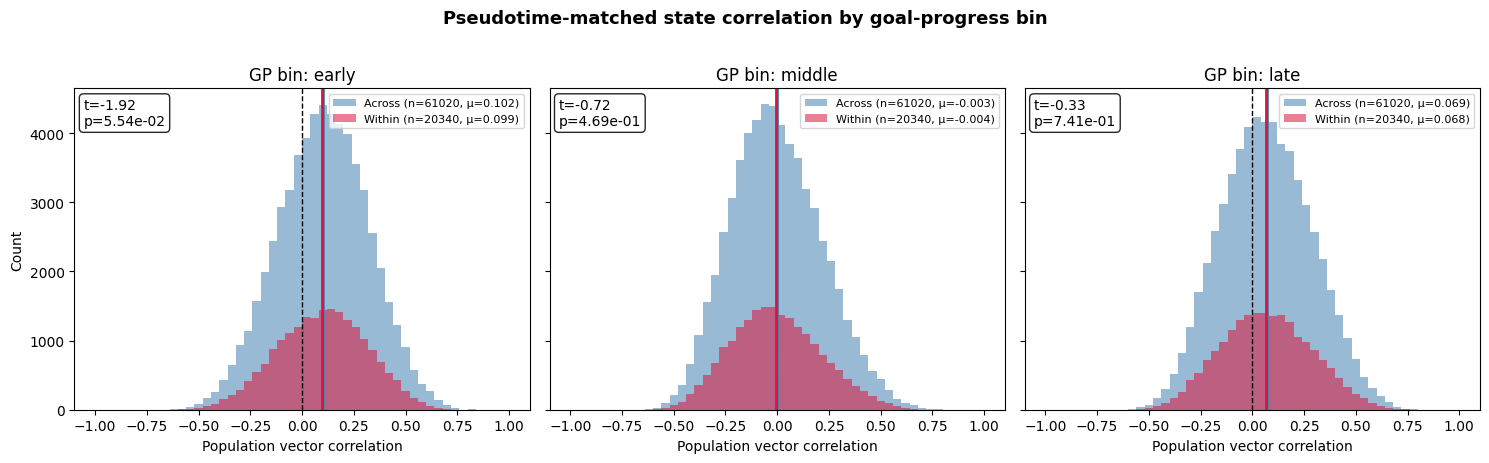


Per-mouse paired test (within - across) by gp bin:
  early   : n_mice=5  Δ=-0.0019  t=-0.68  p=5.36e-01
  middle  : n_mice=5  Δ=-0.0013  t=-1.33  p=2.53e-01
  late    : n_mice=5  Δ=0.0008  t=0.41  p=7.03e-01


In [66]:
# Pseudotime-matched state correlation, broken down by goal-progress bin.
from lda_state_analysis_trialbins import build_trialbins_gp_dataset

GP_LABELS = ['early', 'middle', 'late']
NUM_GP_BINS = 3

pooled_by_gp = {gp: {'within': [], 'across': []} for gp in range(NUM_GP_BINS)}
per_recday_by_gp = {gp: {} for gp in range(NUM_GP_BINS)}

for mr in mouse_recdays:
    try:
        X, y_state, y_gp, sess_id, trial_id, _ = build_trialbins_gp_dataset(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            neuron_subset=None,
            num_gp_bins=NUM_GP_BINS,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')
        continue

    for gp in range(NUM_GP_BINS):
        mask = y_gp == gp
        if mask.sum() == 0:
            continue
        within, across = compute_pseudotime_state_correlations(
            X[mask], y_state[mask], sess_id[mask], trial_id[mask]
        )
        if not within or not across:
            continue
        w = np.array([d['corr'] for d in within])
        a = np.array([d['corr'] for d in across])
        pooled_by_gp[gp]['within'].append(w)
        pooled_by_gp[gp]['across'].append(a)
        per_recday_by_gp[gp][mr] = (w, a)

# --- Figure: pooled distributions per gp bin (1 x 3) ---
fig, axes = plt.subplots(1, NUM_GP_BINS, figsize=(5 * NUM_GP_BINS, 4.5), sharey=True)
bins = np.linspace(-1, 1, 51)
for gp, gp_label in enumerate(GP_LABELS):
    ax = axes[gp]
    if not pooled_by_gp[gp]['within']:
        ax.set_title(f'{gp_label} - no data')
        continue
    w = np.concatenate(pooled_by_gp[gp]['within'])
    a = np.concatenate(pooled_by_gp[gp]['across'])
    ax.hist(a, bins=bins, color='steelblue', alpha=0.55,
            label=f'Across (n={len(a)}, \u03bc={a.mean():.3f})')
    ax.hist(w, bins=bins, color='crimson', alpha=0.55,
            label=f'Within (n={len(w)}, \u03bc={w.mean():.3f})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(a.mean(), color='steelblue', linewidth=2)
    ax.axvline(w.mean(), color='crimson', linewidth=2)
    t, p = st.ttest_ind(w, a)
    ax.text(0.02, 0.97, f't={t:.2f}\np={p:.2e}',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_xlabel('Population vector correlation')
    if gp == 0:
        ax.set_ylabel('Count')
    ax.set_title(f'GP bin: {gp_label}')
    ax.legend(loc='upper right', fontsize=8)
plt.suptitle('Pseudotime-matched state correlation by goal-progress bin',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Per-mouse paired test per gp bin (most conservative inference) ---
print('\nPer-mouse paired test (within - across) by gp bin:')
for gp in range(NUM_GP_BINS):
    by_mr = per_recday_by_gp[gp]
    if not by_mr:
        print(f'  {GP_LABELS[gp]:8s}: no data')
        continue
    mouse_diffs = []
    for mouse in mice_sorted:
        recdays_m = [mr for mr in by_mr if mr.startswith(mouse + '_')]
        if not recdays_m:
            continue
        w_m = np.concatenate([by_mr[mr][0] for mr in recdays_m])
        a_m = np.concatenate([by_mr[mr][1] for mr in recdays_m])
        mouse_diffs.append(w_m.mean() - a_m.mean())
    md_arr = np.array(mouse_diffs)
    if len(md_arr) >= 2:
        t_m, p_m = st.ttest_1samp(md_arr, 0)
        print(f'  {GP_LABELS[gp]:8s}: n_mice={len(md_arr)}  \u0394={md_arr.mean():.4f}  '
              f't={t_m:.2f}  p={p_m:.2e}')
    else:
        print(f'  {GP_LABELS[gp]:8s}: only {len(md_arr)} mouse(s); skipped')

#### Per-mouse × goal-progress breakdown

Same goal-progress-binned within-vs-across-state analysis as the cell above, but broken out per mouse. Tests whether the phase-specificity of state tuning (if any) is consistent across animals or driven by a subset. Uses the `per_recday_by_gp` data already computed above (no re-fitting).

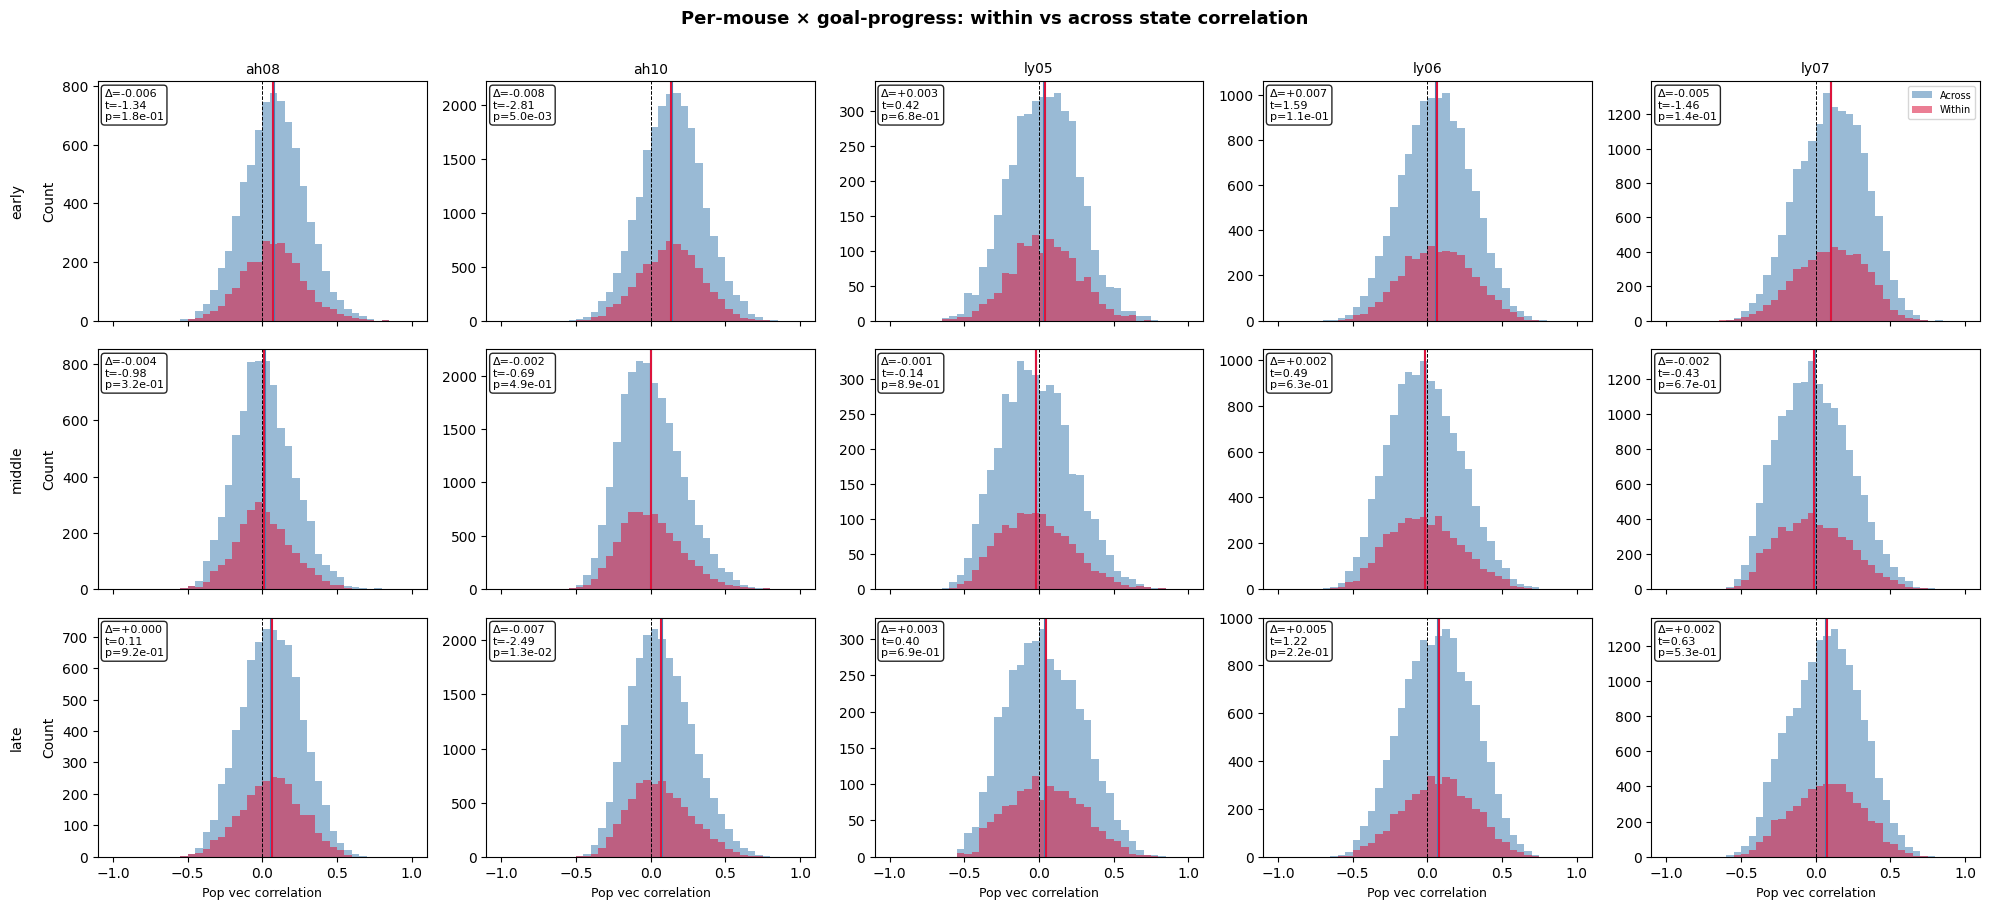

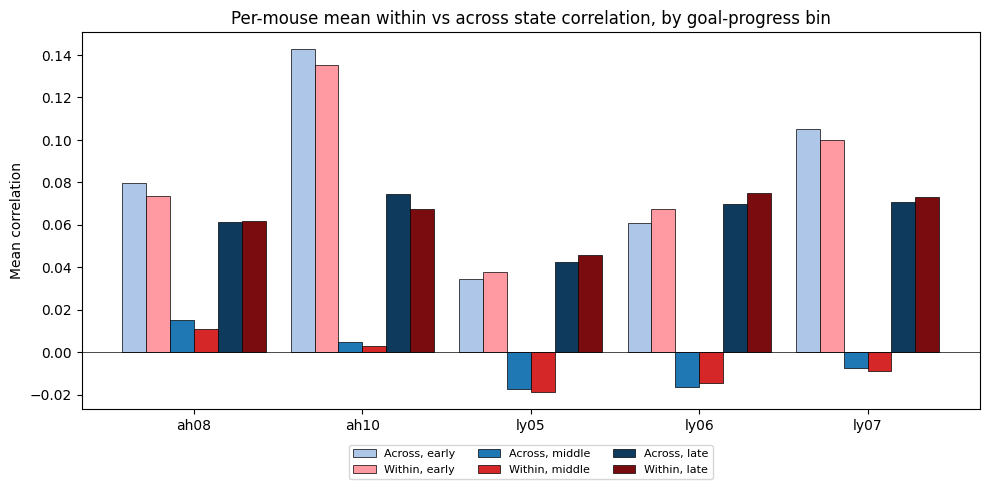

Per-mouse Δ (within - across) by gp bin:
  mouse        early     middle       late
  ah08       -0.0061    -0.0042    +0.0005
  ah10       -0.0076    -0.0019    -0.0068
  ly05       +0.0030    -0.0011    +0.0031
  ly06       +0.0066    +0.0021    +0.0052
  ly07       -0.0053    -0.0016    +0.0023


In [67]:
# Per-mouse × goal-progress aggregation. Reuses per_recday_by_gp from the cell above
# and mice_sorted from the per-mouse cell. No re-extraction needed.

by_mouse_gp = {gp: {} for gp in range(NUM_GP_BINS)}  # {gp: {mouse: (w, a)}}
for gp in range(NUM_GP_BINS):
    for mouse in mice_sorted:
        recdays_m = [mr for mr in per_recday_by_gp[gp] if mr.startswith(mouse + '_')]
        if not recdays_m:
            continue
        w = np.concatenate([per_recday_by_gp[gp][mr][0] for mr in recdays_m])
        a = np.concatenate([per_recday_by_gp[gp][mr][1] for mr in recdays_m])
        by_mouse_gp[gp][mouse] = (w, a)

# --- Figure 1: histogram grid (rows = gp bin, cols = mouse) ---
n_mice = len(mice_sorted)
fig, axes = plt.subplots(NUM_GP_BINS, n_mice, figsize=(4 * n_mice, 3 * NUM_GP_BINS),
                         sharex=True, squeeze=False)
bins = np.linspace(-1, 1, 41)
for gp, gp_label in enumerate(GP_LABELS):
    for col, mouse in enumerate(mice_sorted):
        ax = axes[gp, col]
        if mouse not in by_mouse_gp[gp]:
            ax.set_title(f'{mouse}\n{gp_label} (no data)', fontsize=9)
            ax.axis('off')
            continue
        w, a = by_mouse_gp[gp][mouse]
        ax.hist(a, bins=bins, color='steelblue', alpha=0.55, label='Across')
        ax.hist(w, bins=bins, color='crimson', alpha=0.55, label='Within')
        ax.axvline(0, color='black', linestyle='--', linewidth=0.7)
        ax.axvline(a.mean(), color='steelblue', linewidth=1.5)
        ax.axvline(w.mean(), color='crimson', linewidth=1.5)
        t, p = st.ttest_ind(w, a)
        ax.text(0.02, 0.97,
                f'\u0394={w.mean() - a.mean():+.3f}\nt={t:.2f}\np={p:.1e}',
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        if gp == 0:
            ax.set_title(f'{mouse}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{gp_label}\n\nCount', fontsize=10)
        if gp == NUM_GP_BINS - 1:
            ax.set_xlabel('Pop vec correlation', fontsize=9)
        if gp == 0 and col == n_mice - 1:
            ax.legend(loc='upper right', fontsize=7)
plt.suptitle('Per-mouse × goal-progress: within vs across state correlation',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# --- Figure 2: per-mouse grouped bar chart (within/across × gp bin) ---
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.85 / (2 * NUM_GP_BINS)
x = np.arange(n_mice)
gp_colors_within = ['#ff9aa2', '#d62728', '#7a0c10']
gp_colors_across = ['#aec7e8', '#1f77b4', '#0e3a5e']
for gp, gp_label in enumerate(GP_LABELS):
    a_means = [by_mouse_gp[gp][m][1].mean() if m in by_mouse_gp[gp] else np.nan for m in mice_sorted]
    w_means = [by_mouse_gp[gp][m][0].mean() if m in by_mouse_gp[gp] else np.nan for m in mice_sorted]
    offset_a = (gp * 2 - NUM_GP_BINS + 0.5) * bar_width
    offset_w = (gp * 2 - NUM_GP_BINS + 1.5) * bar_width
    ax.bar(x + offset_a, a_means, width=bar_width, color=gp_colors_across[gp],
           edgecolor='black', linewidth=0.5, label=f'Across, {gp_label}')
    ax.bar(x + offset_w, w_means, width=bar_width, color=gp_colors_within[gp],
           edgecolor='black', linewidth=0.5, label=f'Within, {gp_label}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(mice_sorted)
ax.set_ylabel('Mean correlation')
ax.set_title('Per-mouse mean within vs across state correlation, by goal-progress bin')
ax.legend(ncol=3, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

# --- Per-mouse Δ printout (within - across) by gp bin ---
print('Per-mouse \u0394 (within - across) by gp bin:')
print(f"  {'mouse':6s}  " + ' '.join(f'{lab:>10s}' for lab in GP_LABELS))
for mouse in mice_sorted:
    cells = []
    for gp in range(NUM_GP_BINS):
        if mouse in by_mouse_gp[gp]:
            w, a = by_mouse_gp[gp][mouse]
            cells.append(f'{w.mean() - a.mean():+.4f}')
        else:
            cells.append('     ---')
    print(f"  {mouse:6s}  " + ' '.join(f'{c:>10s}' for c in cells))

## Goal-progress LDA

Splits each (trial, state) into early / middle / late goal-progress bins and fits a separate 4-class LDA within each bin. Useful for asking whether state representation changes across the approach-to-reward trajectory.


Goal-progress LDA analysis: ly07_20250624_20250625
Sessions: [0, 2, 3, 6, 7]
Task is [2 6 4 8]
Task is [3 9 5 2]
Task is [5 7 4 6]
Task is [8 6 5 3]
Task is [6 7 5 3]
ly07_20250624_20250625: 5 sessions, 86 neurons
  Session 0 (index 0): 24 trials, T=46857 samples
  Session 2 (index 1): 43 trials, T=47053 samples
  Session 3 (index 2): 10 trials, T=46012 samples
  Session 6 (index 3): 48 trials, T=51640 samples
  Session 7 (index 4): 36 trials, T=47480 samples
  Dataset: 1932 samples (0 skipped) from 1932 (trial, state, bin) triples
    early: 644 samples
    middle: 644 samples
    late: 644 samples

------------------------------------------------------------
  Progress bin: EARLY
------------------------------------------------------------
  PCA: keeping 29/86 PCs (75.7% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 644
Number of LDA components: 3
Explained variance ratio: [0.54264383 0.34296561 0.11439056]


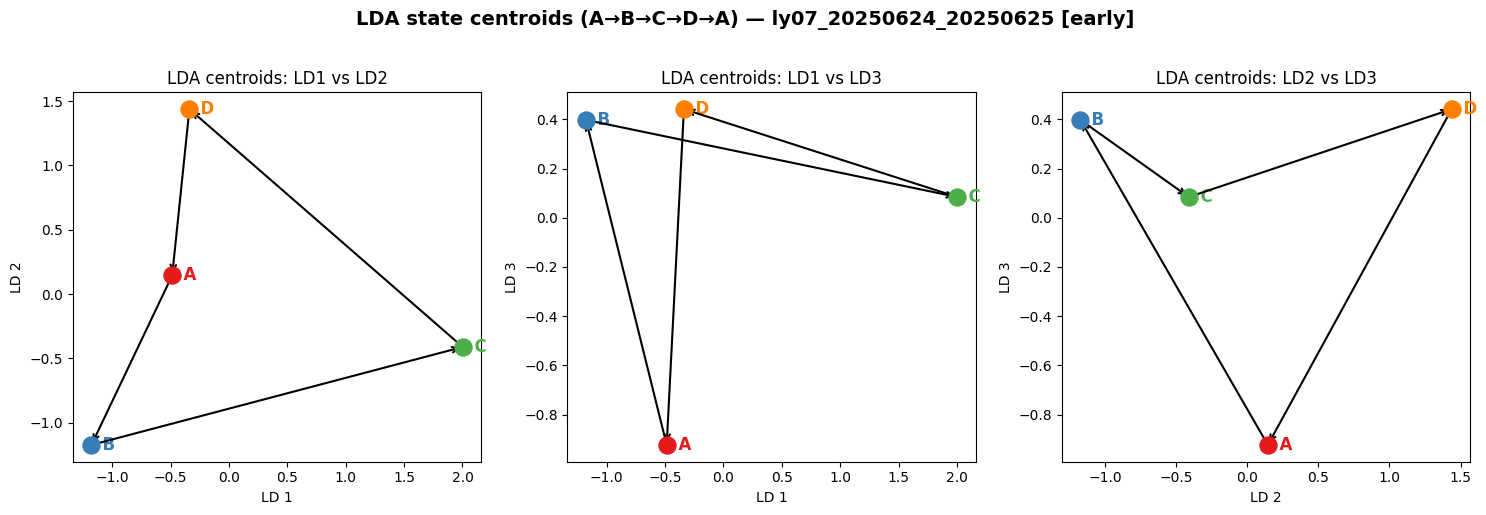

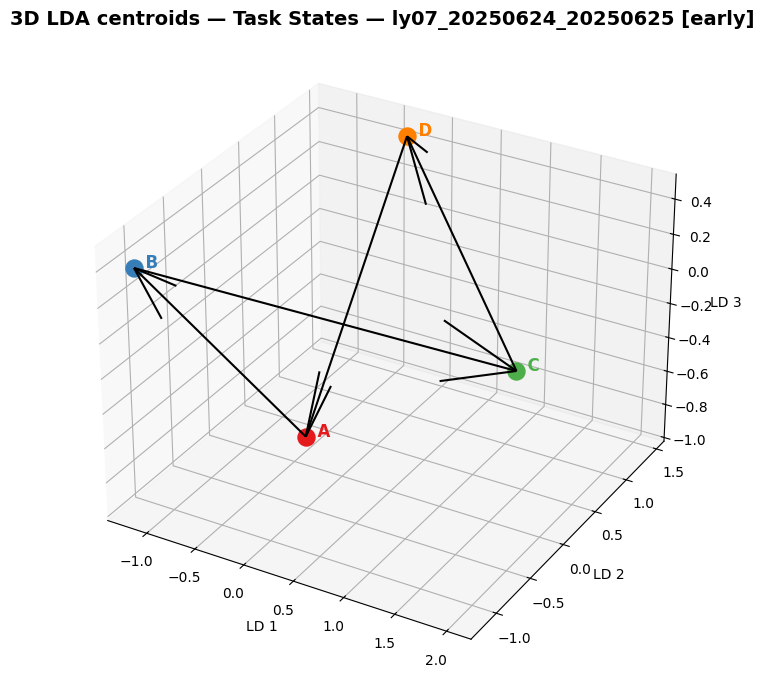

Working with sessions [0 1 2 3 4] (total 5)


Leave-one-session-out CV (5 sessions)
Real CV balanced accuracy: 0.349
Null: 0.249 ± 0.020
p = 0.0000


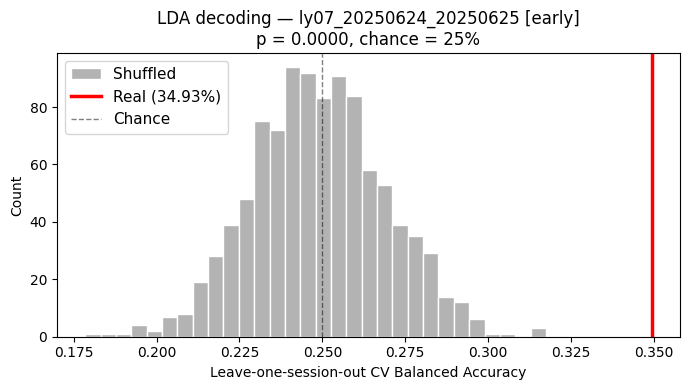


------------------------------------------------------------
  Progress bin: MIDDLE
------------------------------------------------------------
  PCA: keeping 29/86 PCs (75.1% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 644
Number of LDA components: 3
Explained variance ratio: [0.47411557 0.37908472 0.14679971]


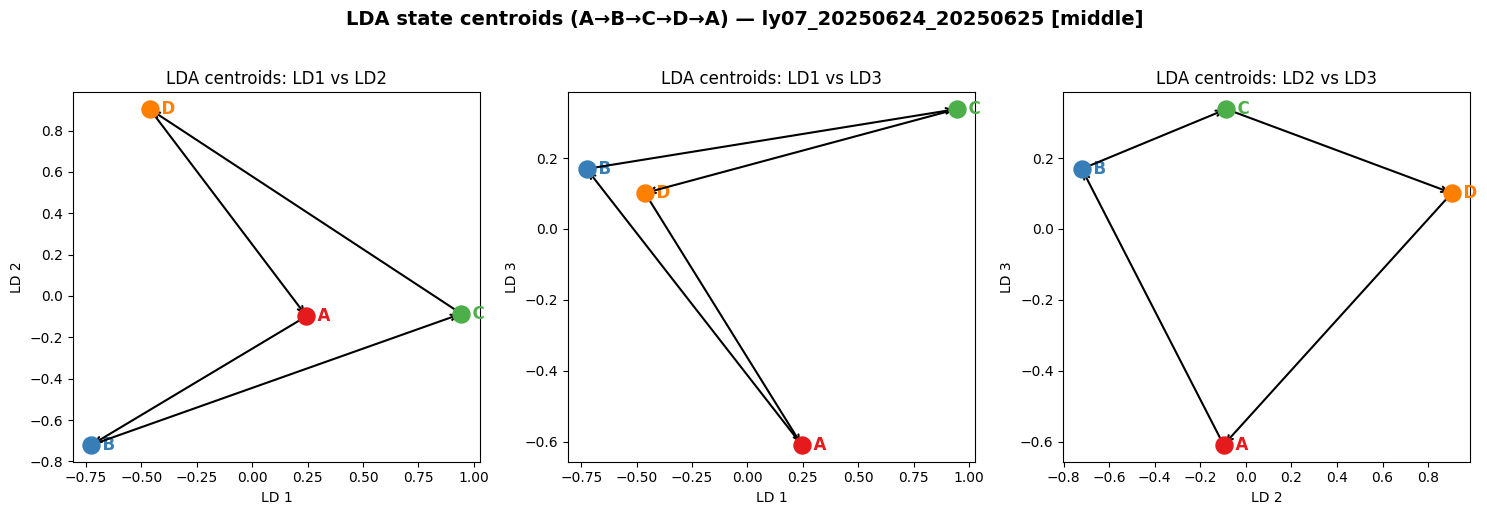

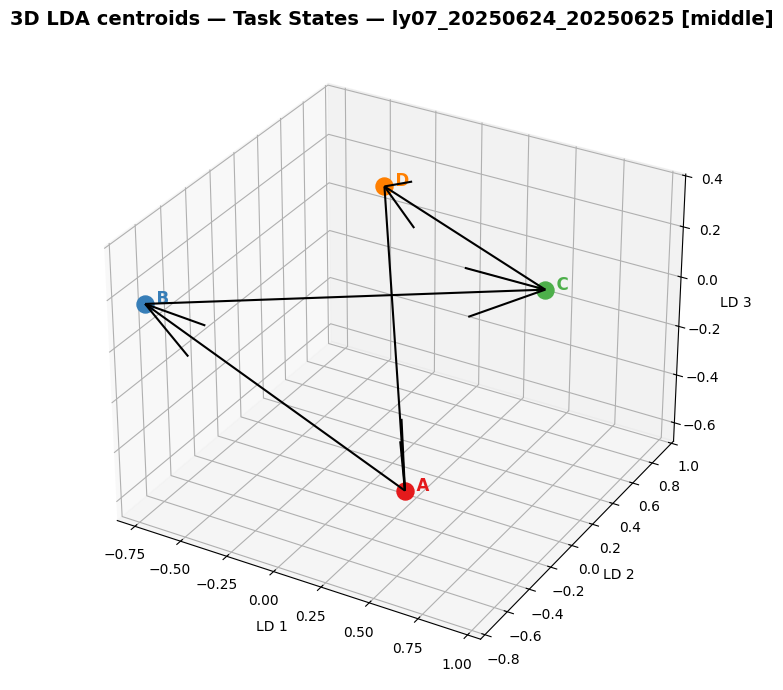

Working with sessions [0 1 2 3 4] (total 5)
Leave-one-session-out CV (5 sessions)
Real CV balanced accuracy: 0.279
Null: 0.251 ± 0.020
p = 0.0770


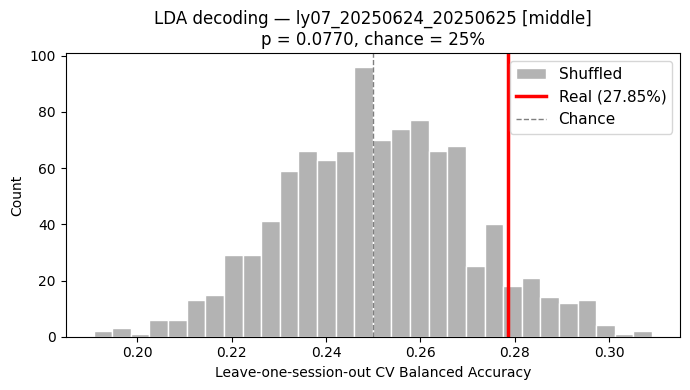


------------------------------------------------------------
  Progress bin: LATE
------------------------------------------------------------
  PCA: keeping 24/86 PCs (75.4% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 644
Number of LDA components: 3
Explained variance ratio: [0.58168788 0.29915657 0.11915555]


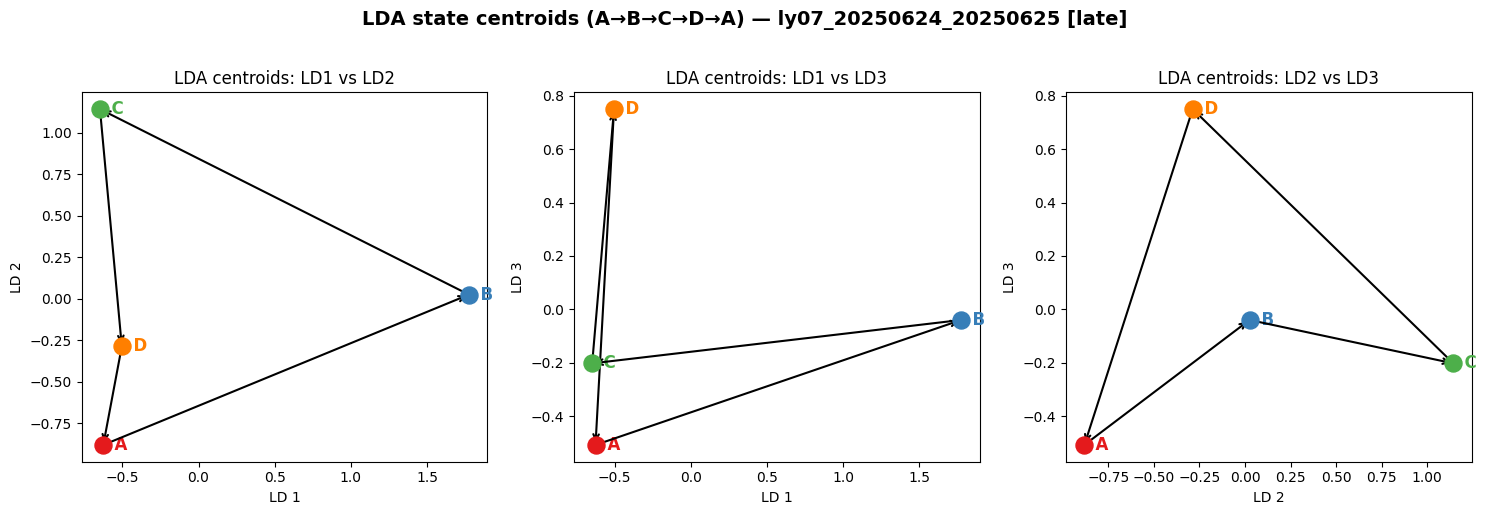

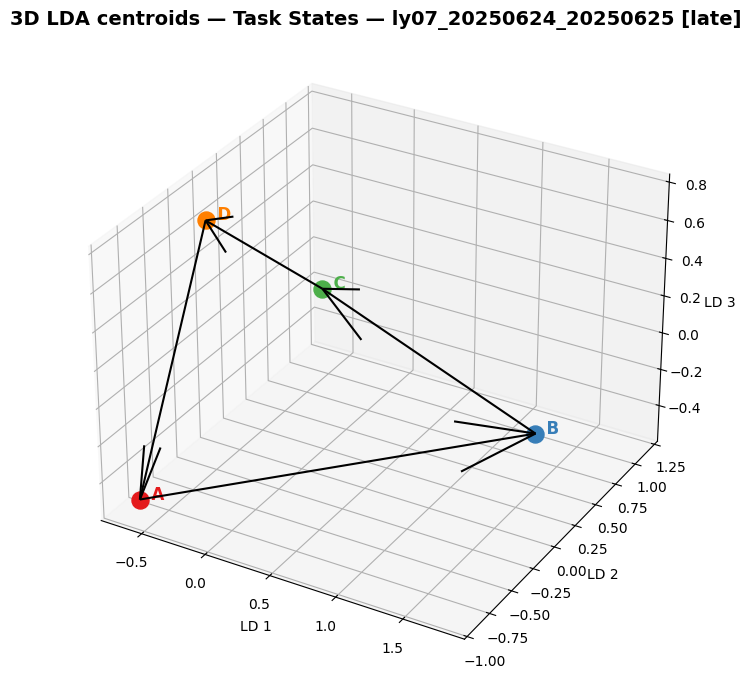

Working with sessions [0 1 2 3 4] (total 5)
Leave-one-session-out CV (5 sessions)
Real CV balanced accuracy: 0.253
Null: 0.250 ± 0.019
p = 0.4530


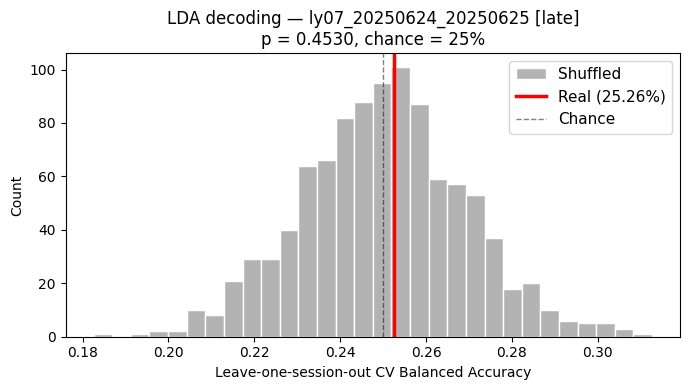


Summary — ly07_20250624_20250625
  early   : acc=0.349  p=0.000  n=644 samples
  middle  : acc=0.279  p=0.077  n=644 samples
  late    : acc=0.253  p=0.453  n=644 samples

Computing null centroids with 1000 circular label rolls...


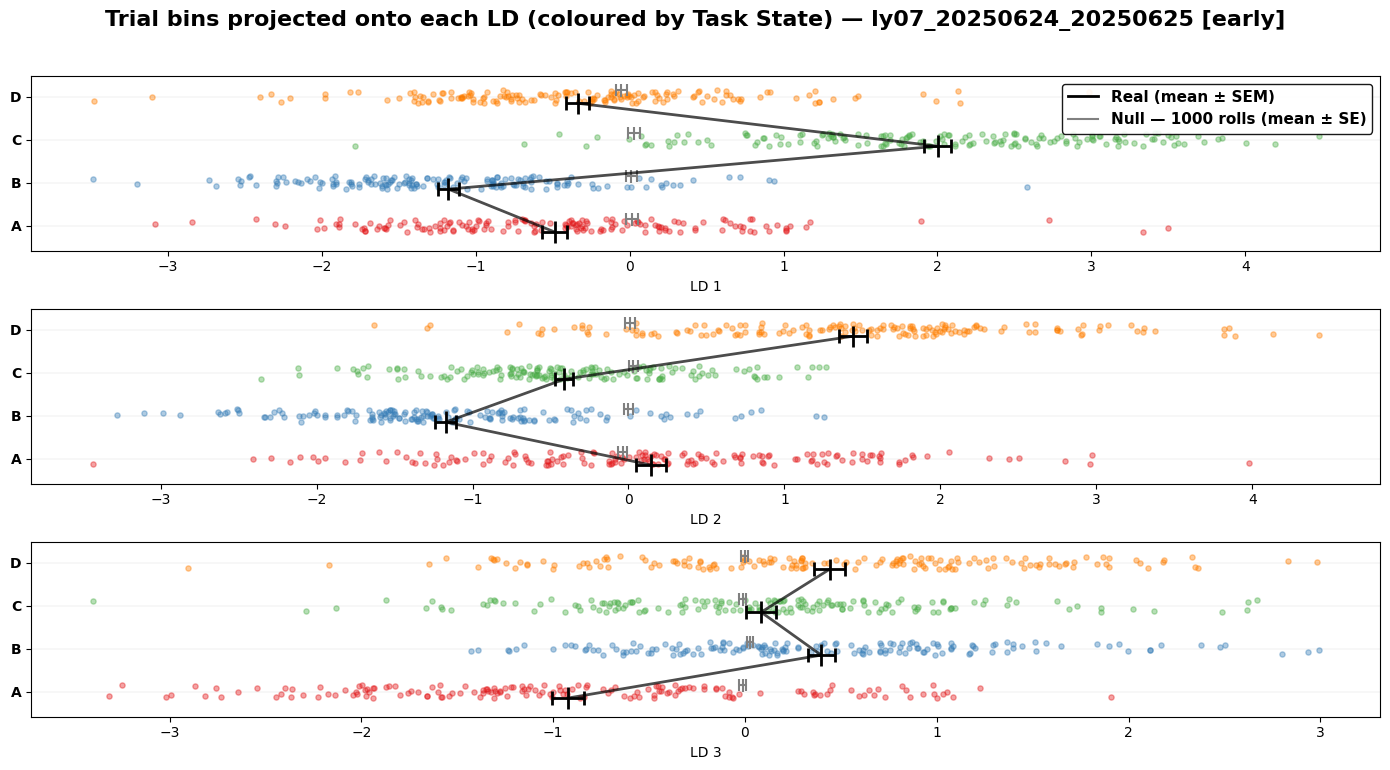

Computing null centroids with 1000 circular label rolls...


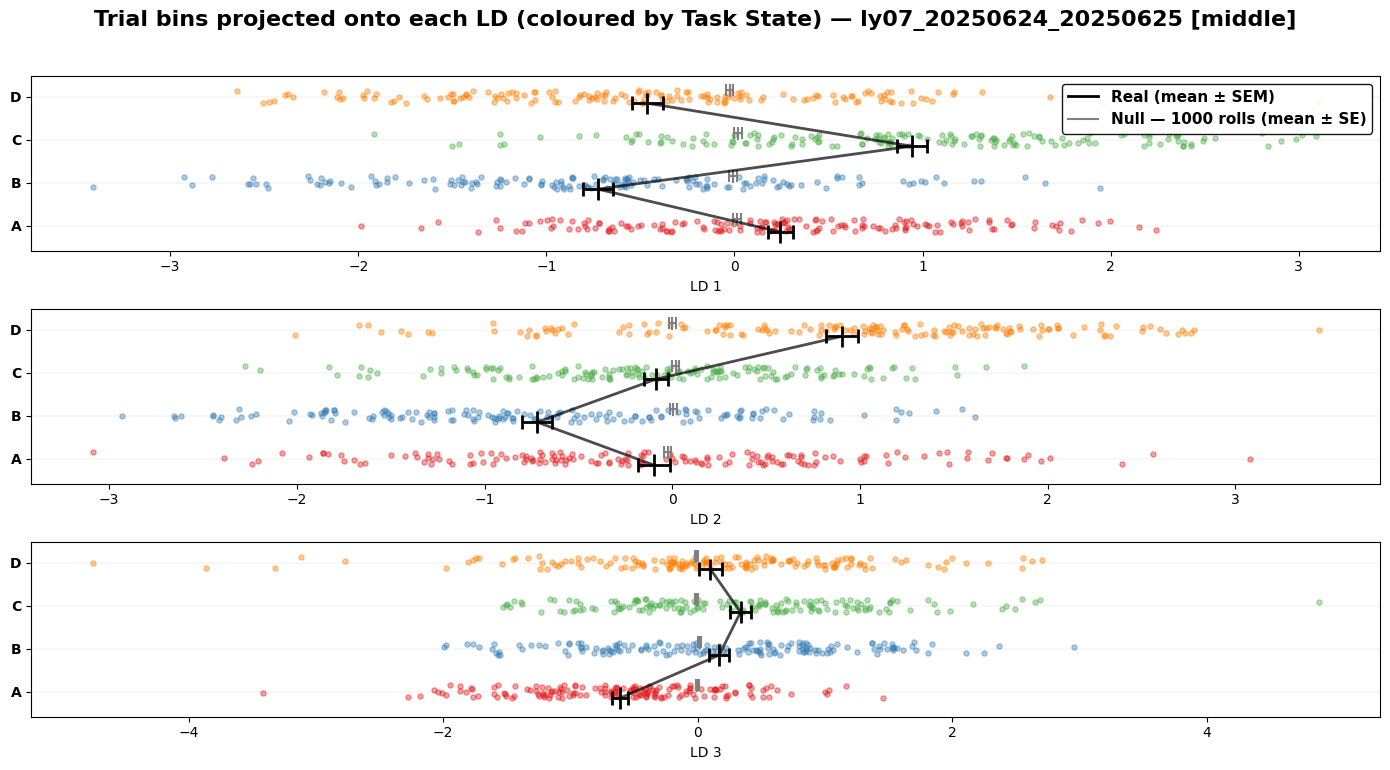

Computing null centroids with 1000 circular label rolls...


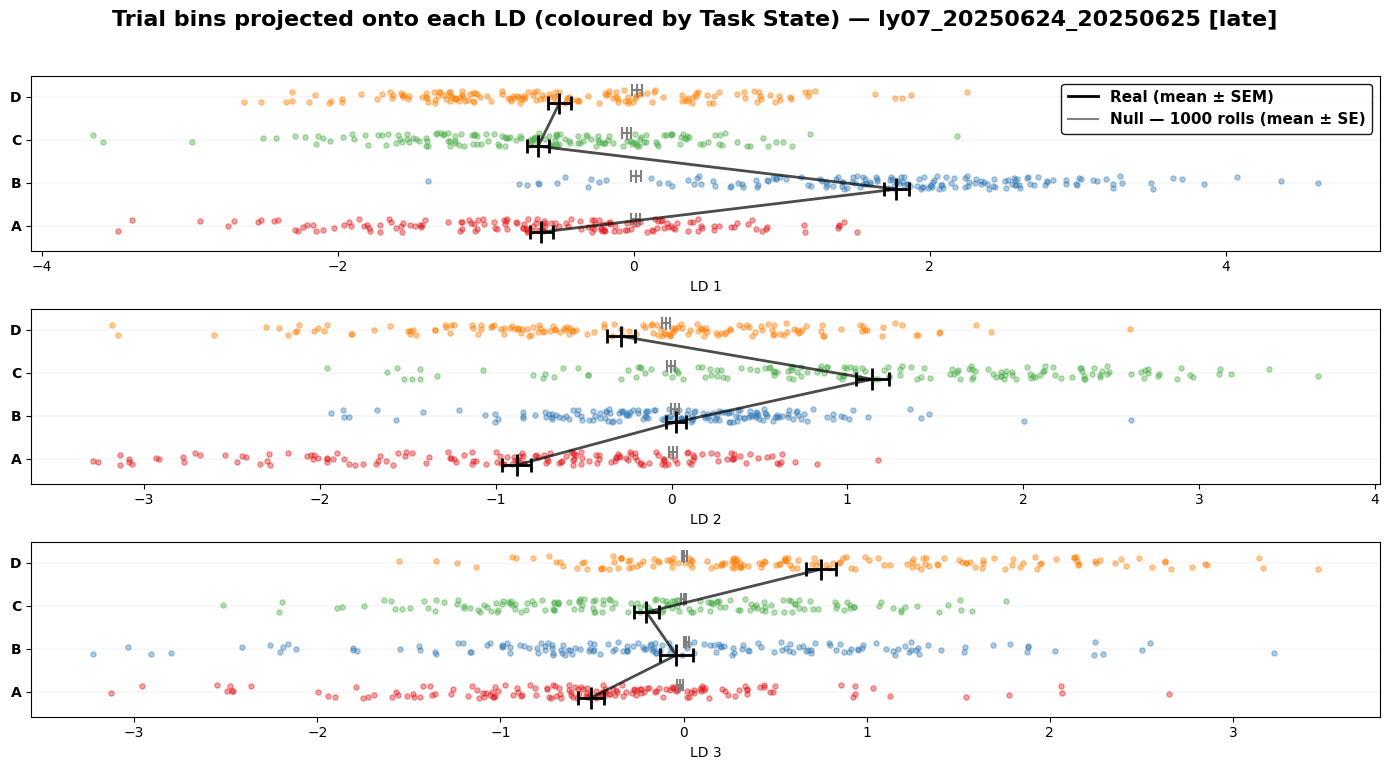

In [68]:
import lda_state_analysis_goalprogress
reload(lda_state_analysis_goalprogress)
from lda_state_analysis_goalprogress import run_goalprogress_lda_analysis

gp_results = run_goalprogress_lda_analysis(
    data_dic, mouse_recday,
    valid_sessions=valid_sessions_dic[mouse_recday],
    neuron_subset=None,
)

for bin_label, r in gp_results.items():
    if r is not None:
        plot_ld_projections(r['X_state_ld'], r['y_state'],
                            EVENT_LABELS, EVENT_COLOURS,
                            f'{mouse_recday} [{bin_label}]')

## Reward × goal-progress LDA

Joint decoding analysis: fits LDA to discriminate reward number AND goal-progress phase. Run across all mouse_recdays and aggregate confusion matrices.

In [ ]:
# Reward x goal-progress LDA -- LD1 ~ reward number (time in session), LD2 ~ goal progress.
# RUN_MODE 'load' reads the pickle written on the cluster by code/run_lda_reward_progress.py
#   (sbatch sbatch_files/lda_reward_progress.sbatch lec); 'run' recomputes here, which is slow
#   (1000-shuffle null per recday x 2 targets) and should not be done for all recdays inside the
#   64 GB interactive cgroup. Cluster run 2026-09-14: all recdays, min_trials=10, 1000 shuffles.
RUN_MODE = 'load'

import lda_reward_goalprogress
reload(lda_reward_goalprogress)
from lda_reward_goalprogress import (
    run_reward_progress_lda_analysis,
    run_reward_progress_decoding,
    plot_aggregate_confusion_matrix,
    plot_decoding_summary,
    load_reward_progress_results,
    reward_progress_table,
)

if RUN_MODE == 'load':
    payload = load_reward_progress_results('lec')
    results_by_recday = payload['results_by_recday']
    decoding_results = payload['decoding_results']
    print(f"loaded {len(results_by_recday)} recdays (min_trials={payload['min_trials']}, "
          f"{payload['n_shuffles']} shuffles); skipped: {payload['skipped']}")
    display(reward_progress_table(payload).round(3))
else:
    decoding_results = {}
    results_by_recday = {}
    for mr in mouse_recdays:
        rp_results = run_reward_progress_lda_analysis(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            neuron_subset=None,
            min_trials=10,
        )
        if rp_results is None:
            continue
        results_by_recday[mr] = rp_results
        decoding_results[mr] = {}
        for target in ['progress', 'reward']:
            real_acc, null_accs, p_val = run_reward_progress_decoding(
                rp_results, decode_target=target, mouse_recday=mr,
            )
            decoding_results[mr][target] = {
                'real_acc': real_acc,
                'null_accs': null_accs,
                'p_value': p_val,
            }

plot_decoding_summary(decoding_results)
for target in ['progress', 'reward']:
    plot_aggregate_confusion_matrix(results_by_recday, decode_target=target)


## LEC vs PFC: time-in-session against goal-progress decoding

Per-recday LOGO-CV balanced accuracy from the two cluster runs. Open markers are per-mouse means
(mice are the replicates), the grey band is the shuffle null, the dashed line is chance. A dataset
whose pickle has not landed yet is skipped with a note.

In [ ]:
from lda_reward_goalprogress import plot_lec_vs_pfc_decoding
fig, cmp_table = plot_lec_vs_pfc_decoding(
    out_path='/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/lda_reward_progress/lec_vs_pfc_decoding.svg')
display(cmp_table.groupby('dataset')[['progress_acc', 'progress_p', 'reward_acc', 'reward_p']]
        .agg(['mean', 'median', 'count']).round(3))
